## New York Taxi Trip Duration Regression

### Imports

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

In [52]:
%config InlineBackend.figure_format = 'retina'

### Loading Dataset

In [53]:
df = pd.read_csv("data/NYC.csv")

df.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


In [54]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1458644 non-null  str    
 1   vendor_id           1458644 non-null  int64  
 2   pickup_datetime     1458644 non-null  str    
 3   dropoff_datetime    1458644 non-null  str    
 4   passenger_count     1458644 non-null  int64  
 5   pickup_longitude    1458644 non-null  float64
 6   pickup_latitude     1458644 non-null  float64
 7   dropoff_longitude   1458644 non-null  float64
 8   dropoff_latitude    1458644 non-null  float64
 9   store_and_fwd_flag  1458644 non-null  str    
 10  trip_duration       1458644 non-null  int64  
dtypes: float64(4), int64(3), str(4)
memory usage: 122.4 MB


### Handling Null Values, Duplicates and unncessairy columns

In [55]:
print(df.isnull().sum())
print(df.duplicated().sum())

id                    0
vendor_id             0
pickup_datetime       0
dropoff_datetime      0
passenger_count       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude     0
dropoff_latitude      0
store_and_fwd_flag    0
trip_duration         0
dtype: int64
0


In [56]:
## id is irrelevant for the model
## dropoff_datetime to prevent data leakage
df.drop(columns=["dropoff_datetime", "id"], inplace=True)

### Date Feature Engineering

In [57]:
df["pickup_datetime"] = pd.to_datetime(df["pickup_datetime"])
df["pickup_hour"] = df["pickup_datetime"].dt.hour
df["pickup_dayofweek"] = df["pickup_datetime"].dt.dayofweek
df["pickup_month"] = df["pickup_datetime"].dt.month
df["is_weekend"] = df["pickup_dayofweek"] >= 5

In [58]:
df[[
    "pickup_datetime",
    "pickup_hour",
    "pickup_dayofweek",
    "pickup_month",
    "is_weekend"
]].head()

,pickup_datetime,pickup_hour,pickup_dayofweek,pickup_month,is_weekend
0,2016-03-14 17:24:55,17,0,3,False
1,2016-06-12 00:43:35,0,6,6,True
2,2016-01-19 11:35:24,11,1,1,False
3,2016-04-06 19:32:31,19,2,4,False
4,2016-03-26 13:30:55,13,5,3,True


In [59]:
df = df.drop(columns=["pickup_datetime"])

In [60]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 12 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   vendor_id           1458644 non-null  int64  
 1   passenger_count     1458644 non-null  int64  
 2   pickup_longitude    1458644 non-null  float64
 3   pickup_latitude     1458644 non-null  float64
 4   dropoff_longitude   1458644 non-null  float64
 5   dropoff_latitude    1458644 non-null  float64
 6   store_and_fwd_flag  1458644 non-null  str    
 7   trip_duration       1458644 non-null  int64  
 8   pickup_hour         1458644 non-null  int32  
 9   pickup_dayofweek    1458644 non-null  int32  
 10  pickup_month        1458644 non-null  int32  
 11  is_weekend          1458644 non-null  bool   
dtypes: bool(1), float64(4), int32(3), int64(3), str(1)
memory usage: 107.1 MB


In [61]:
df['trip_duration'].describe()

count    1.458644e+06
mean     9.594923e+02
std      5.237432e+03
min      1.000000e+00
25%      3.970000e+02
50%      6.620000e+02
75%      1.075000e+03
max      3.526282e+06
Name: trip_duration, dtype: float64

In [62]:
df.sort_values(by='trip_duration', ascending=False).head(10)

,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,pickup_hour,pickup_dayofweek,pickup_month,is_weekend
978383,1,1,-73.783905,40.648632,-73.978271,40.750202,N,3526282,22,5,2,True
924150,1,1,-73.983788,40.742325,-73.985489,40.727676,N,2227612,6,1,1,False
680594,1,2,-73.921677,40.735252,-73.984749,40.759979,N,2049578,22,5,2,True
355003,1,1,-73.789650,40.643559,-73.956810,40.773087,N,1939736,0,1,1,False
1234291,2,2,-73.794525,40.644825,-73.991051,40.755573,N,86392,23,0,2,False
295382,2,1,-73.781952,40.644688,-73.993874,40.745926,N,86391,13,1,5,False
73816,2,1,-73.996010,40.753220,-73.979027,40.740601,N,86390,0,4,5,False
59891,2,1,-73.992279,40.749729,-73.962524,40.800770,N,86387,16,3,6,False
1360439,2,1,-73.782089,40.644806,-73.985016,40.666828,N,86385,16,3,6,False
753765,2,4,-74.006111,40.734680,-73.958809,40.815449,N,86379,22,1,5,False


In [63]:
Q1 = df["trip_duration"].quantile(0.25)
Q3 = df["trip_duration"].quantile(0.75)

IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR

max_non_outlier = df.loc[
    df["trip_duration"] <= upper_bound,
    "trip_duration"
].max()

print("Upper bound:", upper_bound)
print("Maximum non-outlier:", max_non_outlier)

Upper bound: 2092.0
Maximum non-outlier: 2092


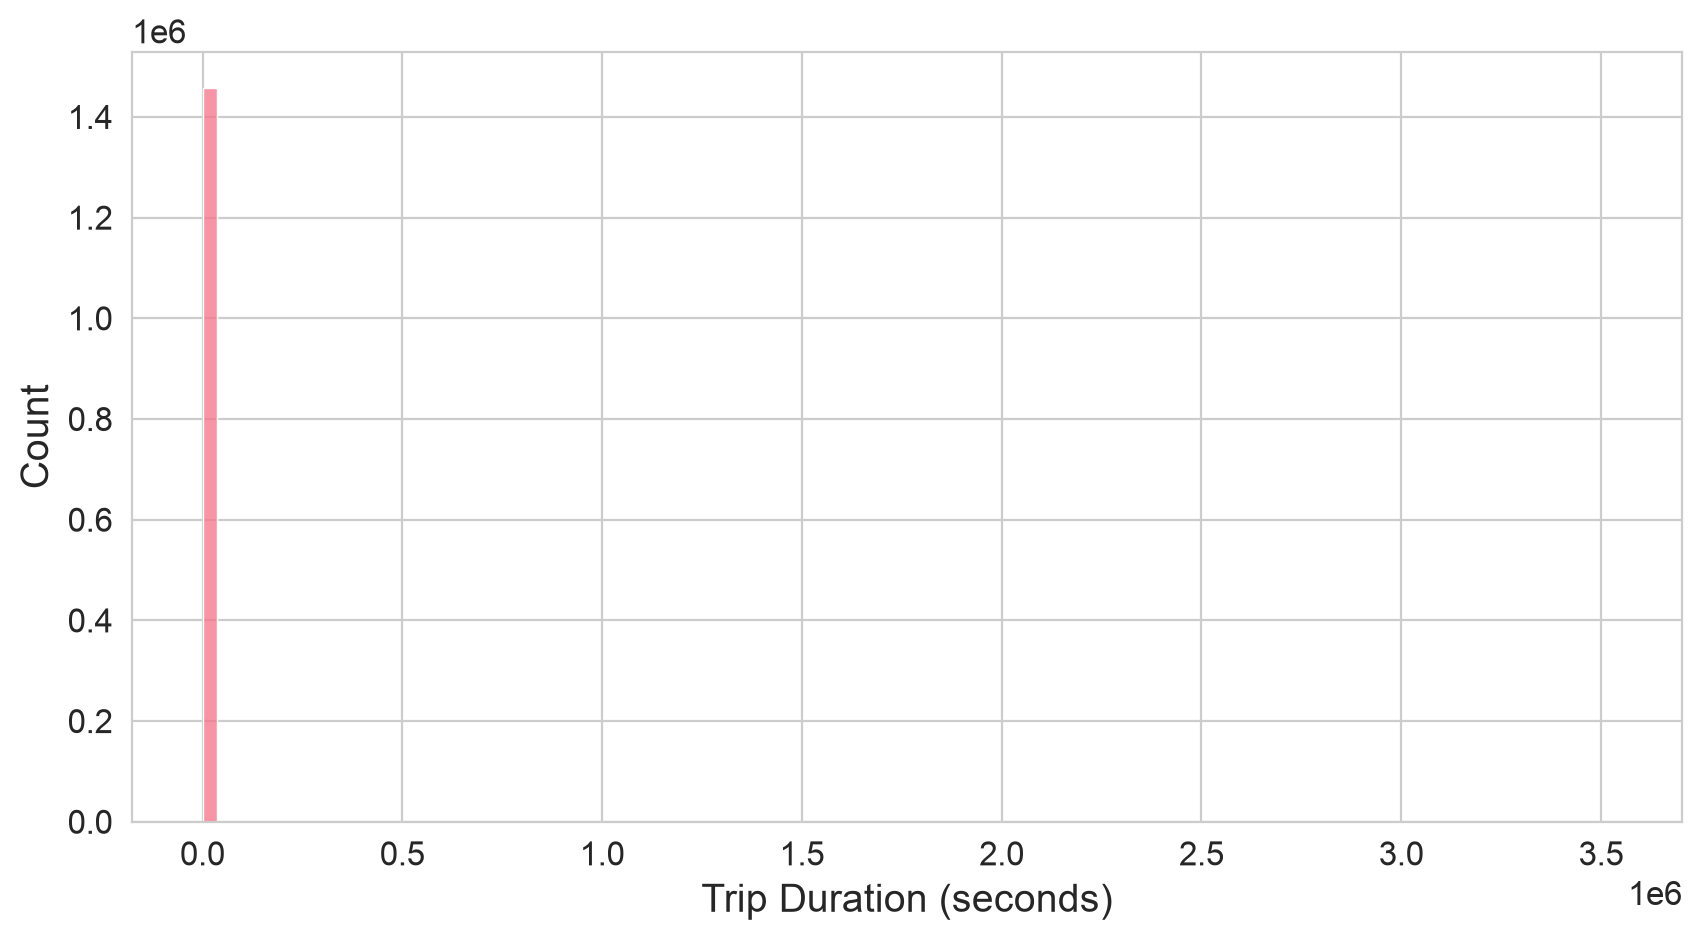

In [64]:
plt.figure(figsize=(10, 5))
sns.histplot(df["trip_duration"], bins=100)
plt.xlabel("Trip Duration (seconds)")
plt.show()

In [65]:
print(
    len(df[df["trip_duration"] > 4000]) / len(df) * 100
)

0.5686102983318754


In [66]:
df =df[df["trip_duration"] <= 4000]

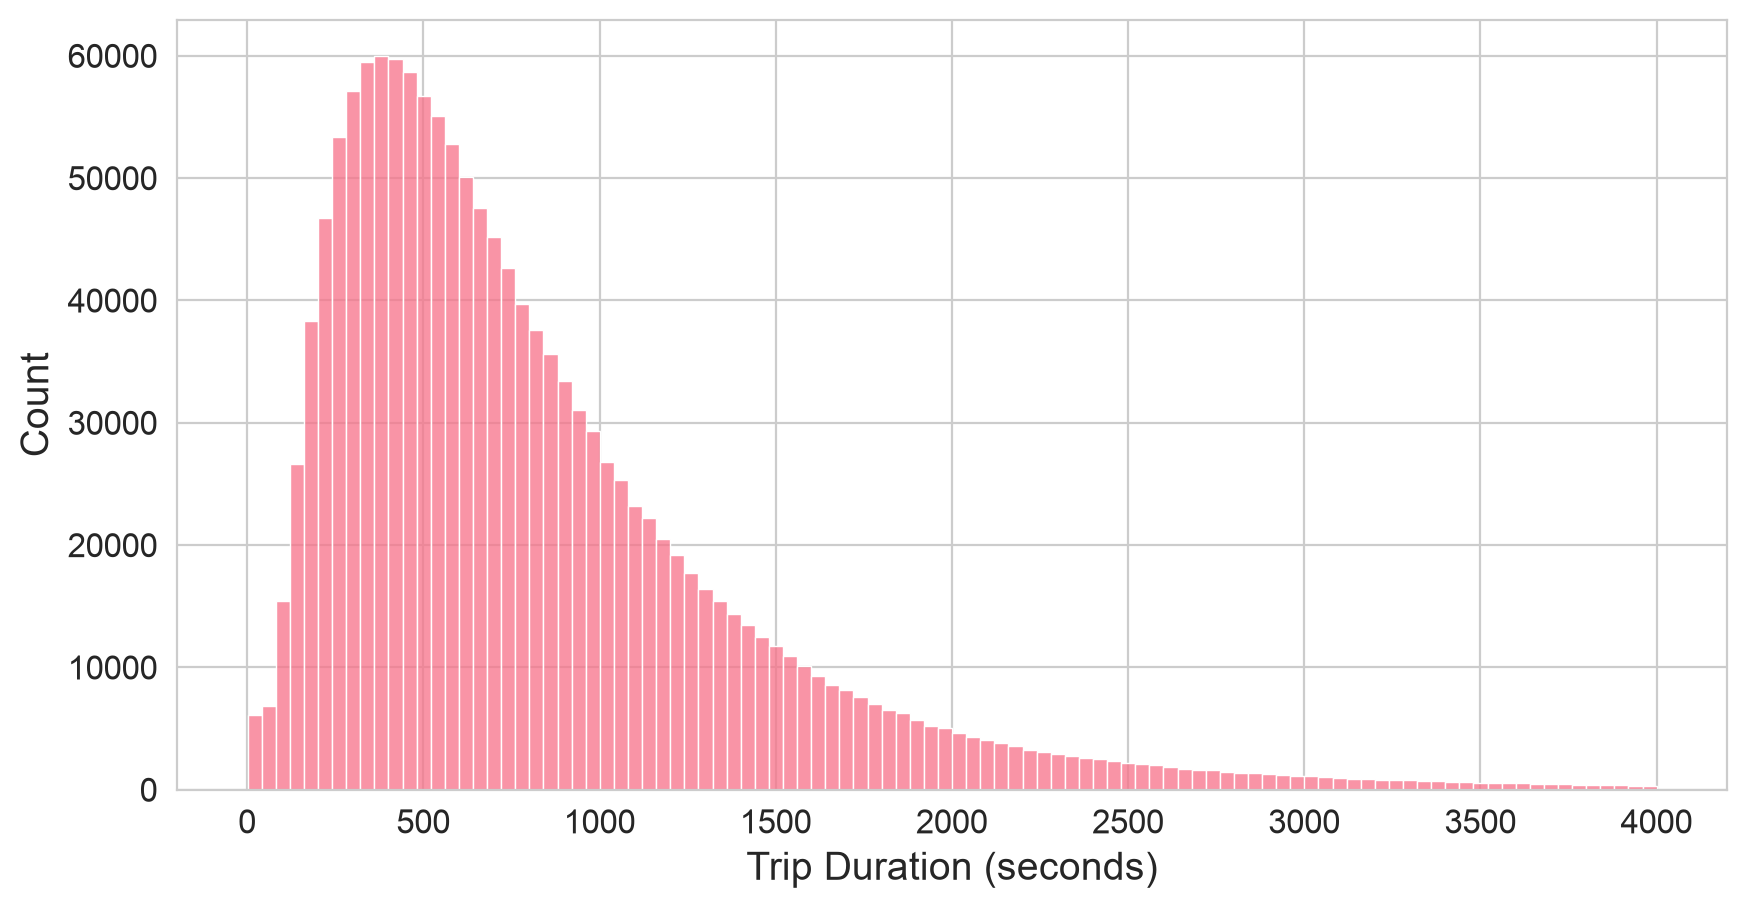

In [67]:
plt.figure(figsize=(10, 5))
sns.histplot(df["trip_duration"], bins=100)
plt.xlabel("Trip Duration (seconds)")
plt.show()

### Transforming rest of data to numerical values

In [68]:
df.info()

<class 'pandas.DataFrame'>
Index: 1450350 entries, 0 to 1458643
Data columns (total 12 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   vendor_id           1450350 non-null  int64  
 1   passenger_count     1450350 non-null  int64  
 2   pickup_longitude    1450350 non-null  float64
 3   pickup_latitude     1450350 non-null  float64
 4   dropoff_longitude   1450350 non-null  float64
 5   dropoff_latitude    1450350 non-null  float64
 6   store_and_fwd_flag  1450350 non-null  str    
 7   trip_duration       1450350 non-null  int64  
 8   pickup_hour         1450350 non-null  int32  
 9   pickup_dayofweek    1450350 non-null  int32  
 10  pickup_month        1450350 non-null  int32  
 11  is_weekend          1450350 non-null  bool   
dtypes: bool(1), float64(4), int32(3), int64(3), str(1)
memory usage: 117.6 MB


In [69]:
df["is_weekend"] = df["is_weekend"].astype(int)

In [70]:
df['store_and_fwd_flag']= df['store_and_fwd_flag'].apply(lambda x: 1 if x == 'Y' else 0).astype(int)
df.head()

,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,pickup_hour,pickup_dayofweek,pickup_month,is_weekend
0,2,1,-73.982155,40.767937,-73.964630,40.765602,0,455,17,0,3,0
1,1,1,-73.980415,40.738564,-73.999481,40.731152,0,663,0,6,6,1
2,2,1,-73.979027,40.763939,-74.005333,40.710087,0,2124,11,1,1,0
3,2,1,-74.010040,40.719971,-74.012268,40.706718,0,429,19,2,4,0
4,2,1,-73.973053,40.793209,-73.972923,40.782520,0,435,13,5,3,1


In [71]:
df["store_and_fwd_flag"].value_counts(normalize=True)

store_and_fwd_flag
0    0.994547
1    0.005453
Name: proportion, dtype: float64

In [72]:
## there is almost no variance, we drop this shit
df.drop('store_and_fwd_flag', axis=1, inplace=True)

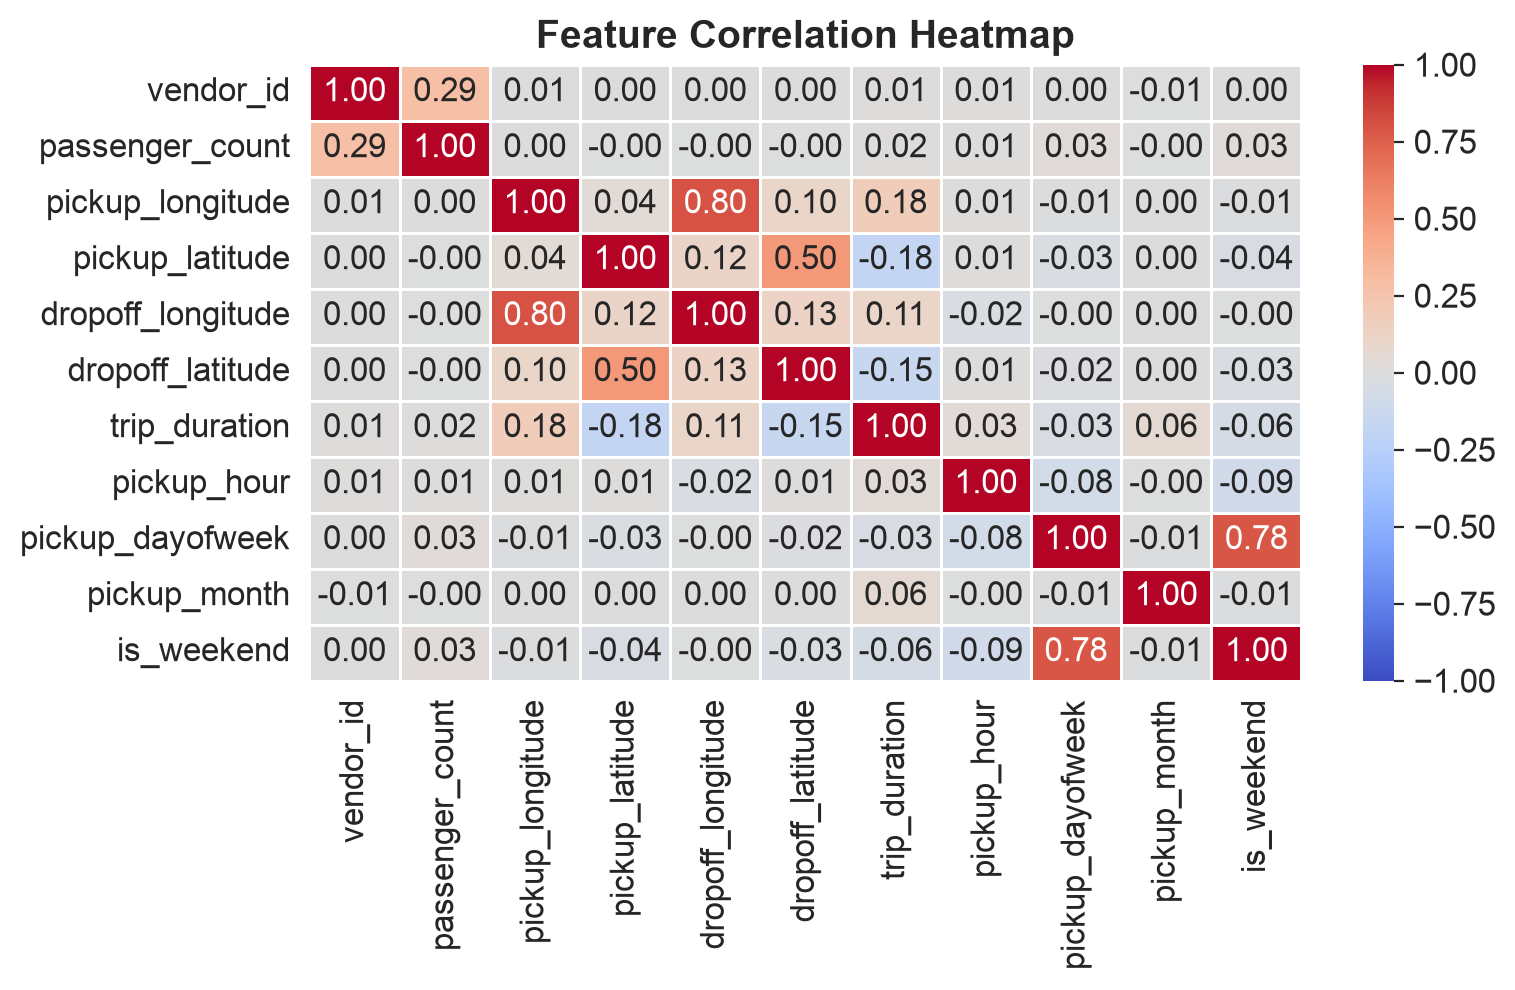

In [73]:

plt.figure(figsize=(8, 4))

# Calculate Pearson correlation matrix
corr_matrix = df.corr(numeric_only=True)

# Plot styled correlation heatmap
sns.heatmap(
    corr_matrix, 
    annot=True,              # Display numerical values in cells
    fmt=".2f",               # Format to 2 decimal places
    cmap="coolwarm",         # Blue = negative correlation, Red = positive correlation
    vmin=-1, vmax=1, 
    linewidths=0.5
)
plt.title("Feature Correlation Heatmap", fontsize=14, fontweight="bold")
plt.show()

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import radians, sin, cos, sqrt, asin

# Set up seaborn style
sns.set_style("whitegrid")
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['legend.fontsize'] = 12

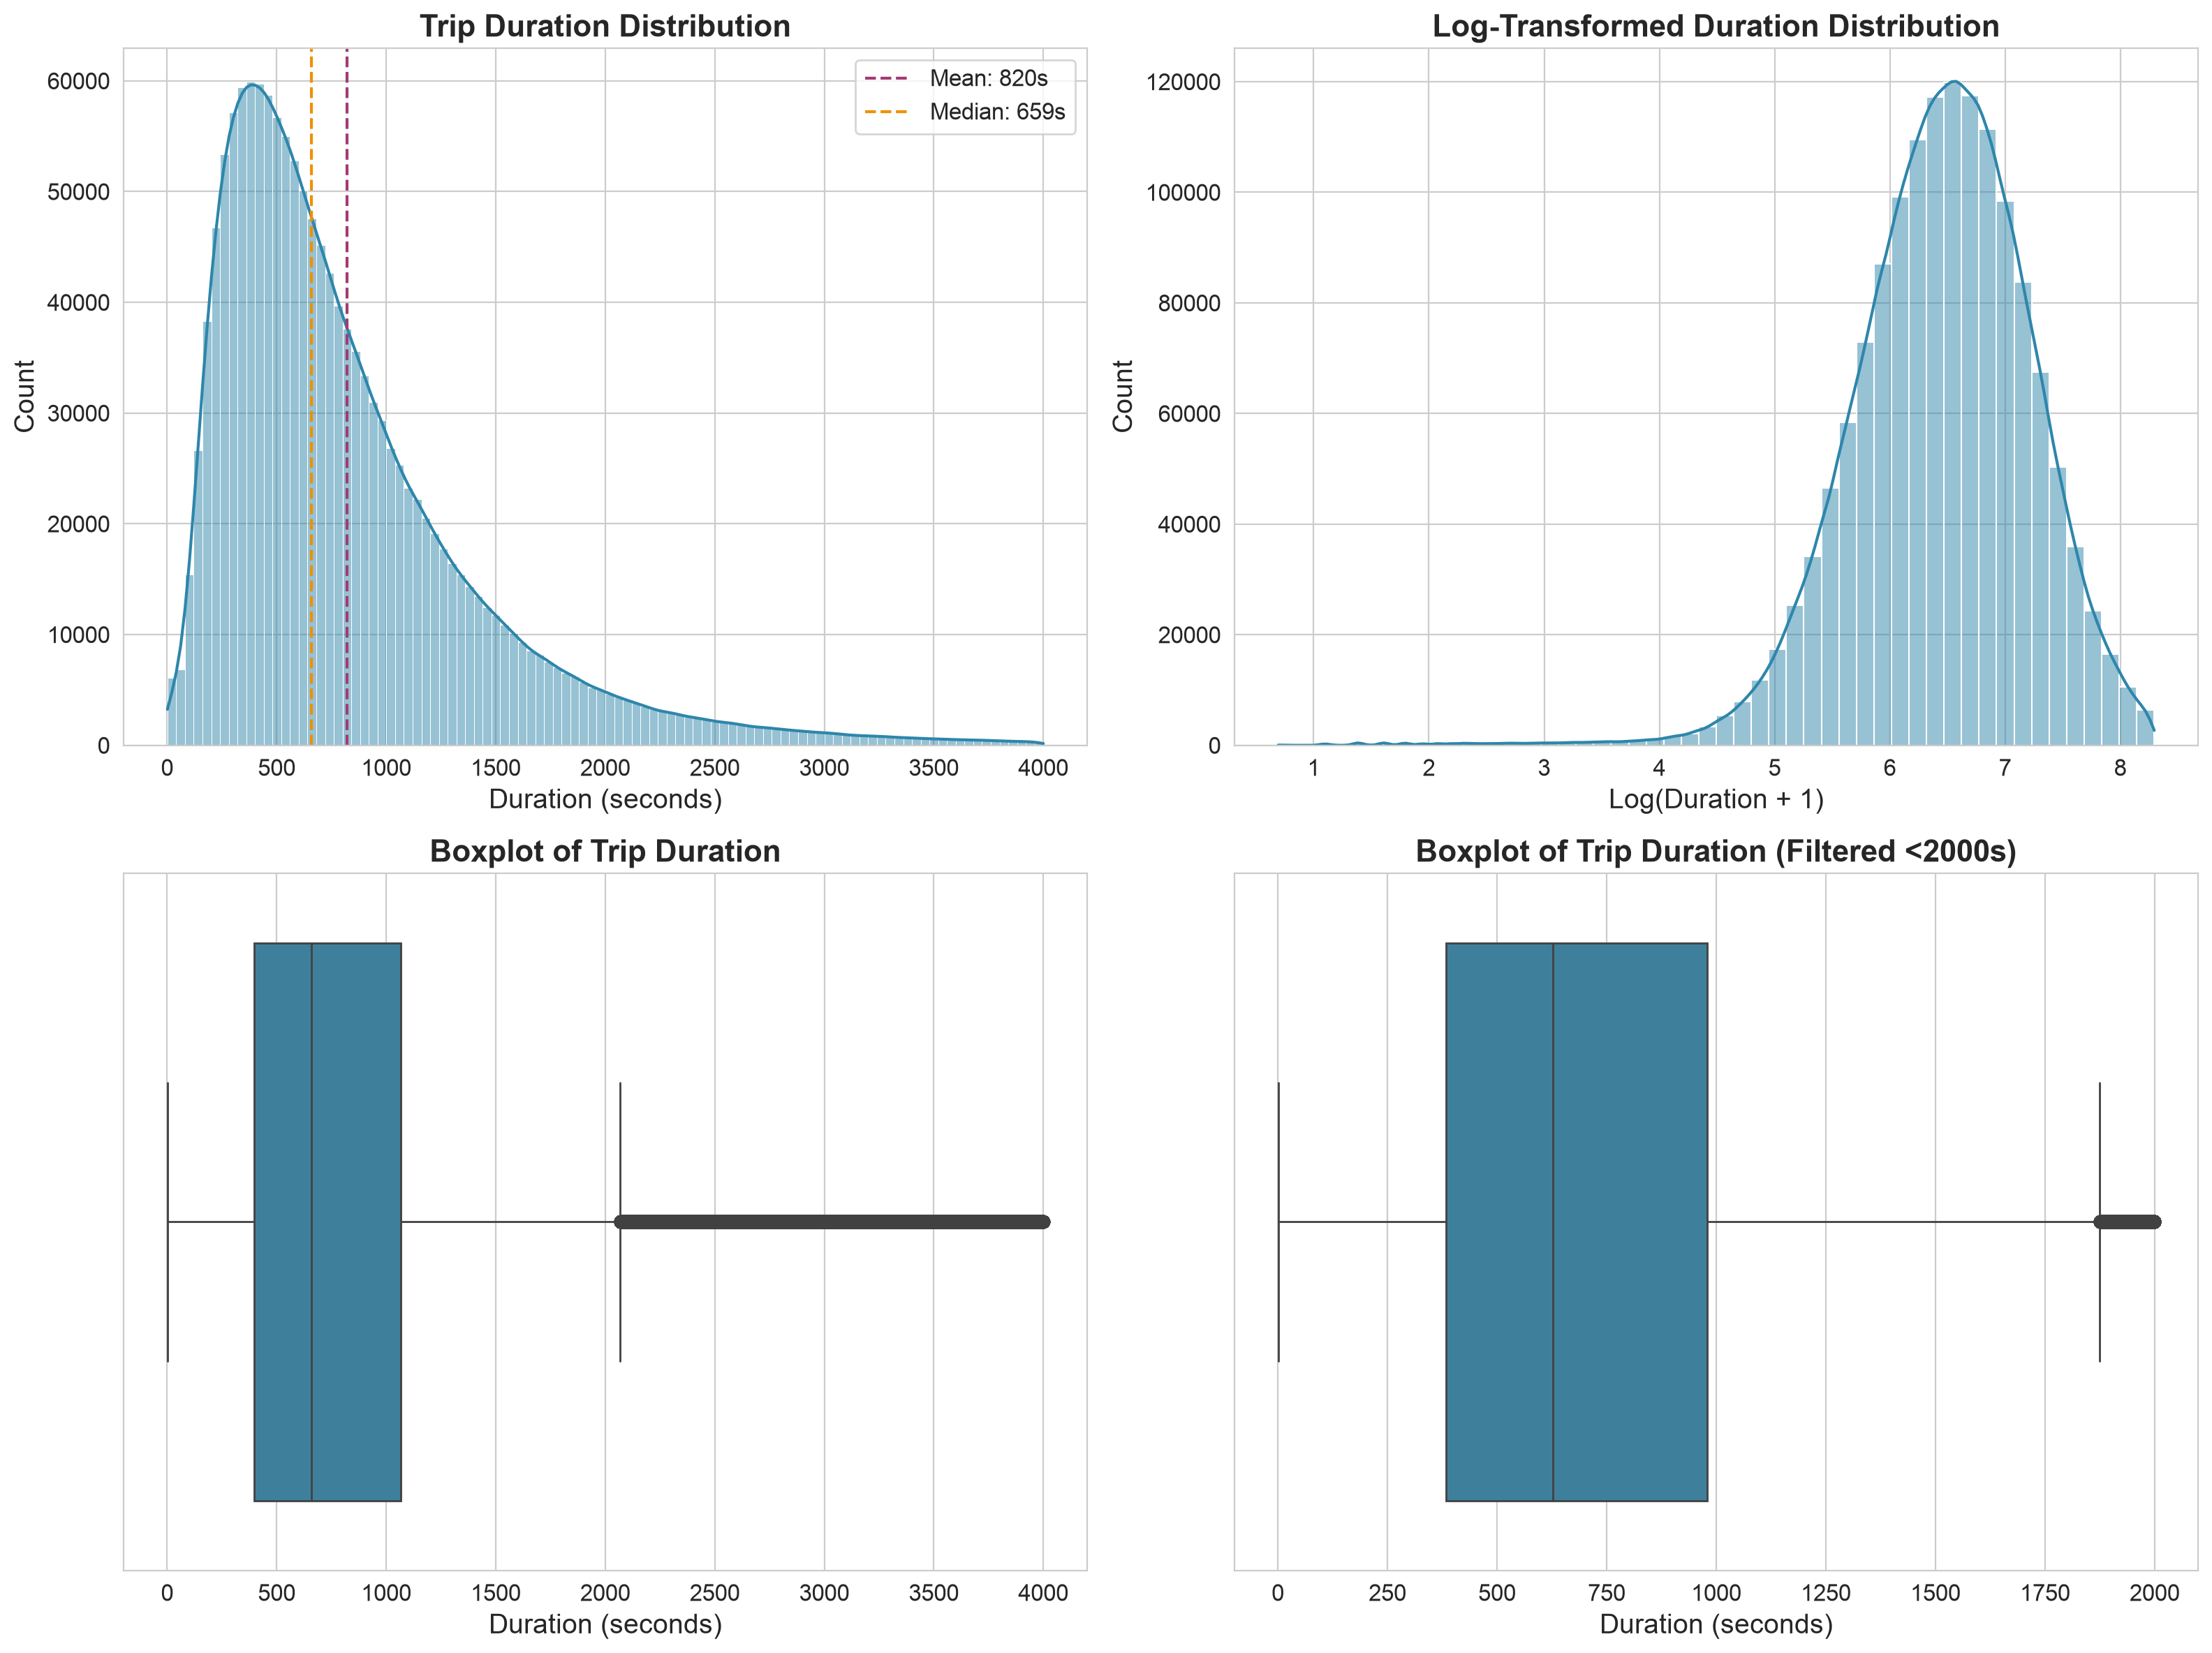

In [75]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Raw distribution
sns.histplot(df['trip_duration'], bins=100, kde=True, ax=axes[0, 0], color='#2E86AB')
axes[0, 0].axvline(df['trip_duration'].mean(), color='#A23B72', linestyle='--', label=f'Mean: {df["trip_duration"].mean():.0f}s')
axes[0, 0].axvline(df['trip_duration'].median(), color='#F18F01', linestyle='--', label=f'Median: {df["trip_duration"].median():.0f}s')
axes[0, 0].set_title('Trip Duration Distribution', fontweight='bold')
axes[0, 0].set_xlabel('Duration (seconds)')
axes[0, 0].legend()

# Log-transformed distribution
sns.histplot(np.log1p(df['trip_duration']), bins=50, kde=True, ax=axes[0, 1], color='#2E86AB')
axes[0, 1].set_title('Log-Transformed Duration Distribution', fontweight='bold')
axes[0, 1].set_xlabel('Log(Duration + 1)')

# Boxplot with outliers
sns.boxplot(x=df['trip_duration'], ax=axes[1, 0], color='#2E86AB')
axes[1, 0].set_title('Boxplot of Trip Duration', fontweight='bold')
axes[1, 0].set_xlabel('Duration (seconds)')

# Boxplot without outliers (zoomed)
filtered_duration = df['trip_duration'][df['trip_duration'] < 2000]
sns.boxplot(x=filtered_duration, ax=axes[1, 1], color='#2E86AB')
axes[1, 1].set_title('Boxplot of Trip Duration (Filtered <2000s)', fontweight='bold')
axes[1, 1].set_xlabel('Duration (seconds)')

plt.tight_layout()
plt.show()

In [109]:
# ==========================================
# 1. DEFINE & CALCULATE DISTANCE FEATURE
# ==========================================

from geopy.distance import geodesic

df["distance_km"] = df.apply(
    lambda row: geodesic(
        (row["pickup_latitude"], row["pickup_longitude"]),
        (row["dropoff_latitude"], row["dropoff_longitude"])
    ).km,
    axis=1
)

# ==========================================
# 2. FILTER OUT BAD DATA
# ==========================================
# Filter out 0km trips and keep only standard trips (< 2 hours)
df_clean = df[(df['distance_km'] > 0.1) & (df['trip_duration'] < 7200)]

# ==========================================
# 3. PLOTTING THE 1x3 GRID (FIXED FOR JUPYTER)
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# --- Plot 1: Hexbin (All Clean Data) ---
hb = axes[0].hexbin(df_clean['distance_km'], df_clean['trip_duration'], 
                     gridsize=50, cmap='YlOrRd', mincnt=1)
axes[0].set_xlabel('Distance (km)')
axes[0].set_ylabel('Duration (seconds)')
axes[0].set_title('Distance vs Duration (Cleaned Data)', fontweight='bold')
plt.colorbar(hb, ax=axes[0], label='Count')

# --- Plot 2: Scatter + Regression (Under 20km) ---
filtered = df_clean[df_clean['distance_km'] < 20]
sns.regplot(x='distance_km', y='trip_duration', data=filtered, ax=axes[1],
            scatter_kws={'alpha': 0.1, 's': 5}, line_kws={'color': 'red'})
axes[1].set_title('Distance vs Duration (<20km)', fontweight='bold')
axes[1].set_xlabel('Distance (km)')
axes[1].set_ylabel('Duration (seconds)')

plt.tight_layout()
plt.show()

# ==========================================
# 4. CORRELATIONS
# ==========================================
print(f"\n{'='*50}")
print(f"Correlation (Cleaned Data): {df_clean['distance_km'].corr(df_clean['trip_duration']):.3f}")
print(f"Correlation (<20km Data):   {filtered['distance_km'].corr(filtered['trip_duration']):.3f}")
# Issue with the third plot:
# The 'Marginal Distributions (<20km)' plot manually overlays scatter and histogram (for both axes) 
# using 'plt.histplot', to mimic 'sns.jointplot(kind="scatter", marginal_kws=...)'.
# While this works for visualizing scatter and both marginal distributions in a single axis,
# it does NOT separate the margins to their own axes the way the standard jointplot does.
# Therefore, the histograms are overlaid on top of the main plot and may obscure data or make 
# the visual less clear, especially with many points or when bins overlap the scatter heavily.
# This approach gives a compact single-axes solution for Jupyter, but at the expense of clarity 
# and standard marginal plot aesthetics. Use with care, especially for crowded or skewed data.

ModuleNotFoundError: No module named 'geopy'

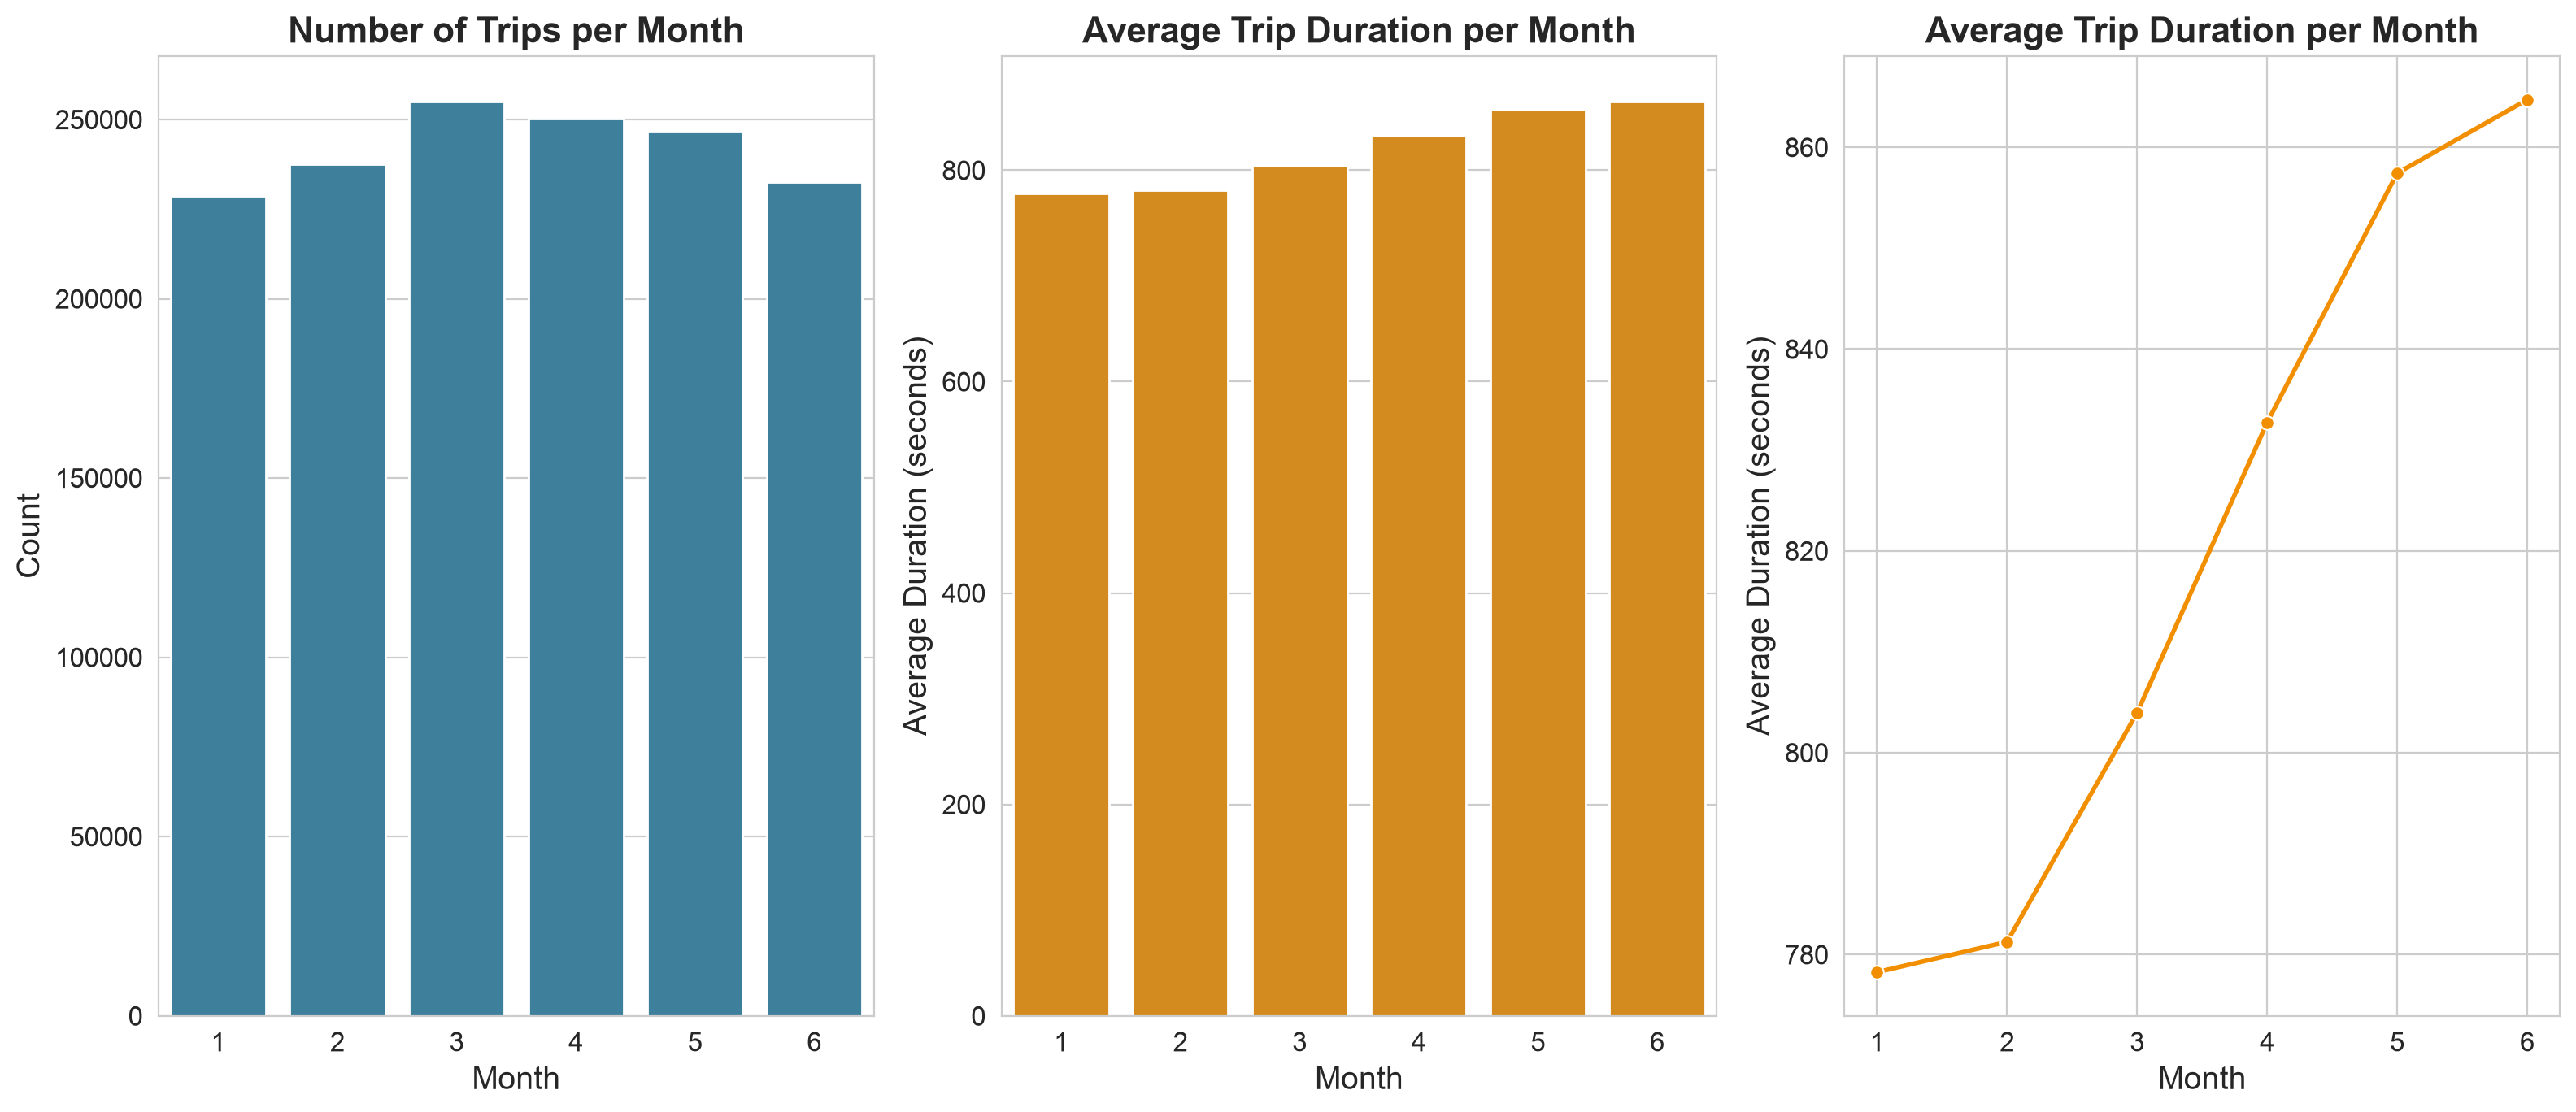

In [101]:
fig, axes = plt.subplots(1, 3, figsize=(16, 7))

# --- Plot 1: Count of Trips per Month ---
# Correct syntax: give it the raw df, and tell it the column names.
sns.barplot(data=df, x='pickup_month', y='trip_duration', 
            ax=axes[0], estimator='size', color='#2E86AB', errorbar=None)
axes[0].set_title('Number of Trips per Month', fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Count')

# --- Plot 2: Average Duration per Month ---
# Correct syntax: change the estimator to 'mean'
sns.barplot(data=df, x='pickup_month', y='trip_duration', 
            ax=axes[1], estimator='mean', color='#F18F01', errorbar=None)
axes[1].set_title('Average Trip Duration per Month', fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Average Duration (seconds)')

# Replace the second bar plot with this:
monthly_mean = df.groupby('pickup_month')['trip_duration'].mean().reset_index()
sns.lineplot(data=monthly_mean, x='pickup_month', y='trip_duration', 
             ax=axes[2], marker='o', color='#F18F01', linewidth=2)
axes[2].set_title('Average Trip Duration per Month', fontweight='bold')
axes[2].set_xlabel('Month')
axes[2].set_ylabel('Average Duration (seconds)')

plt.tight_layout()
plt.show()

In [ ]:
# there is an upward trend, hence there is a pattern. So we should leave it

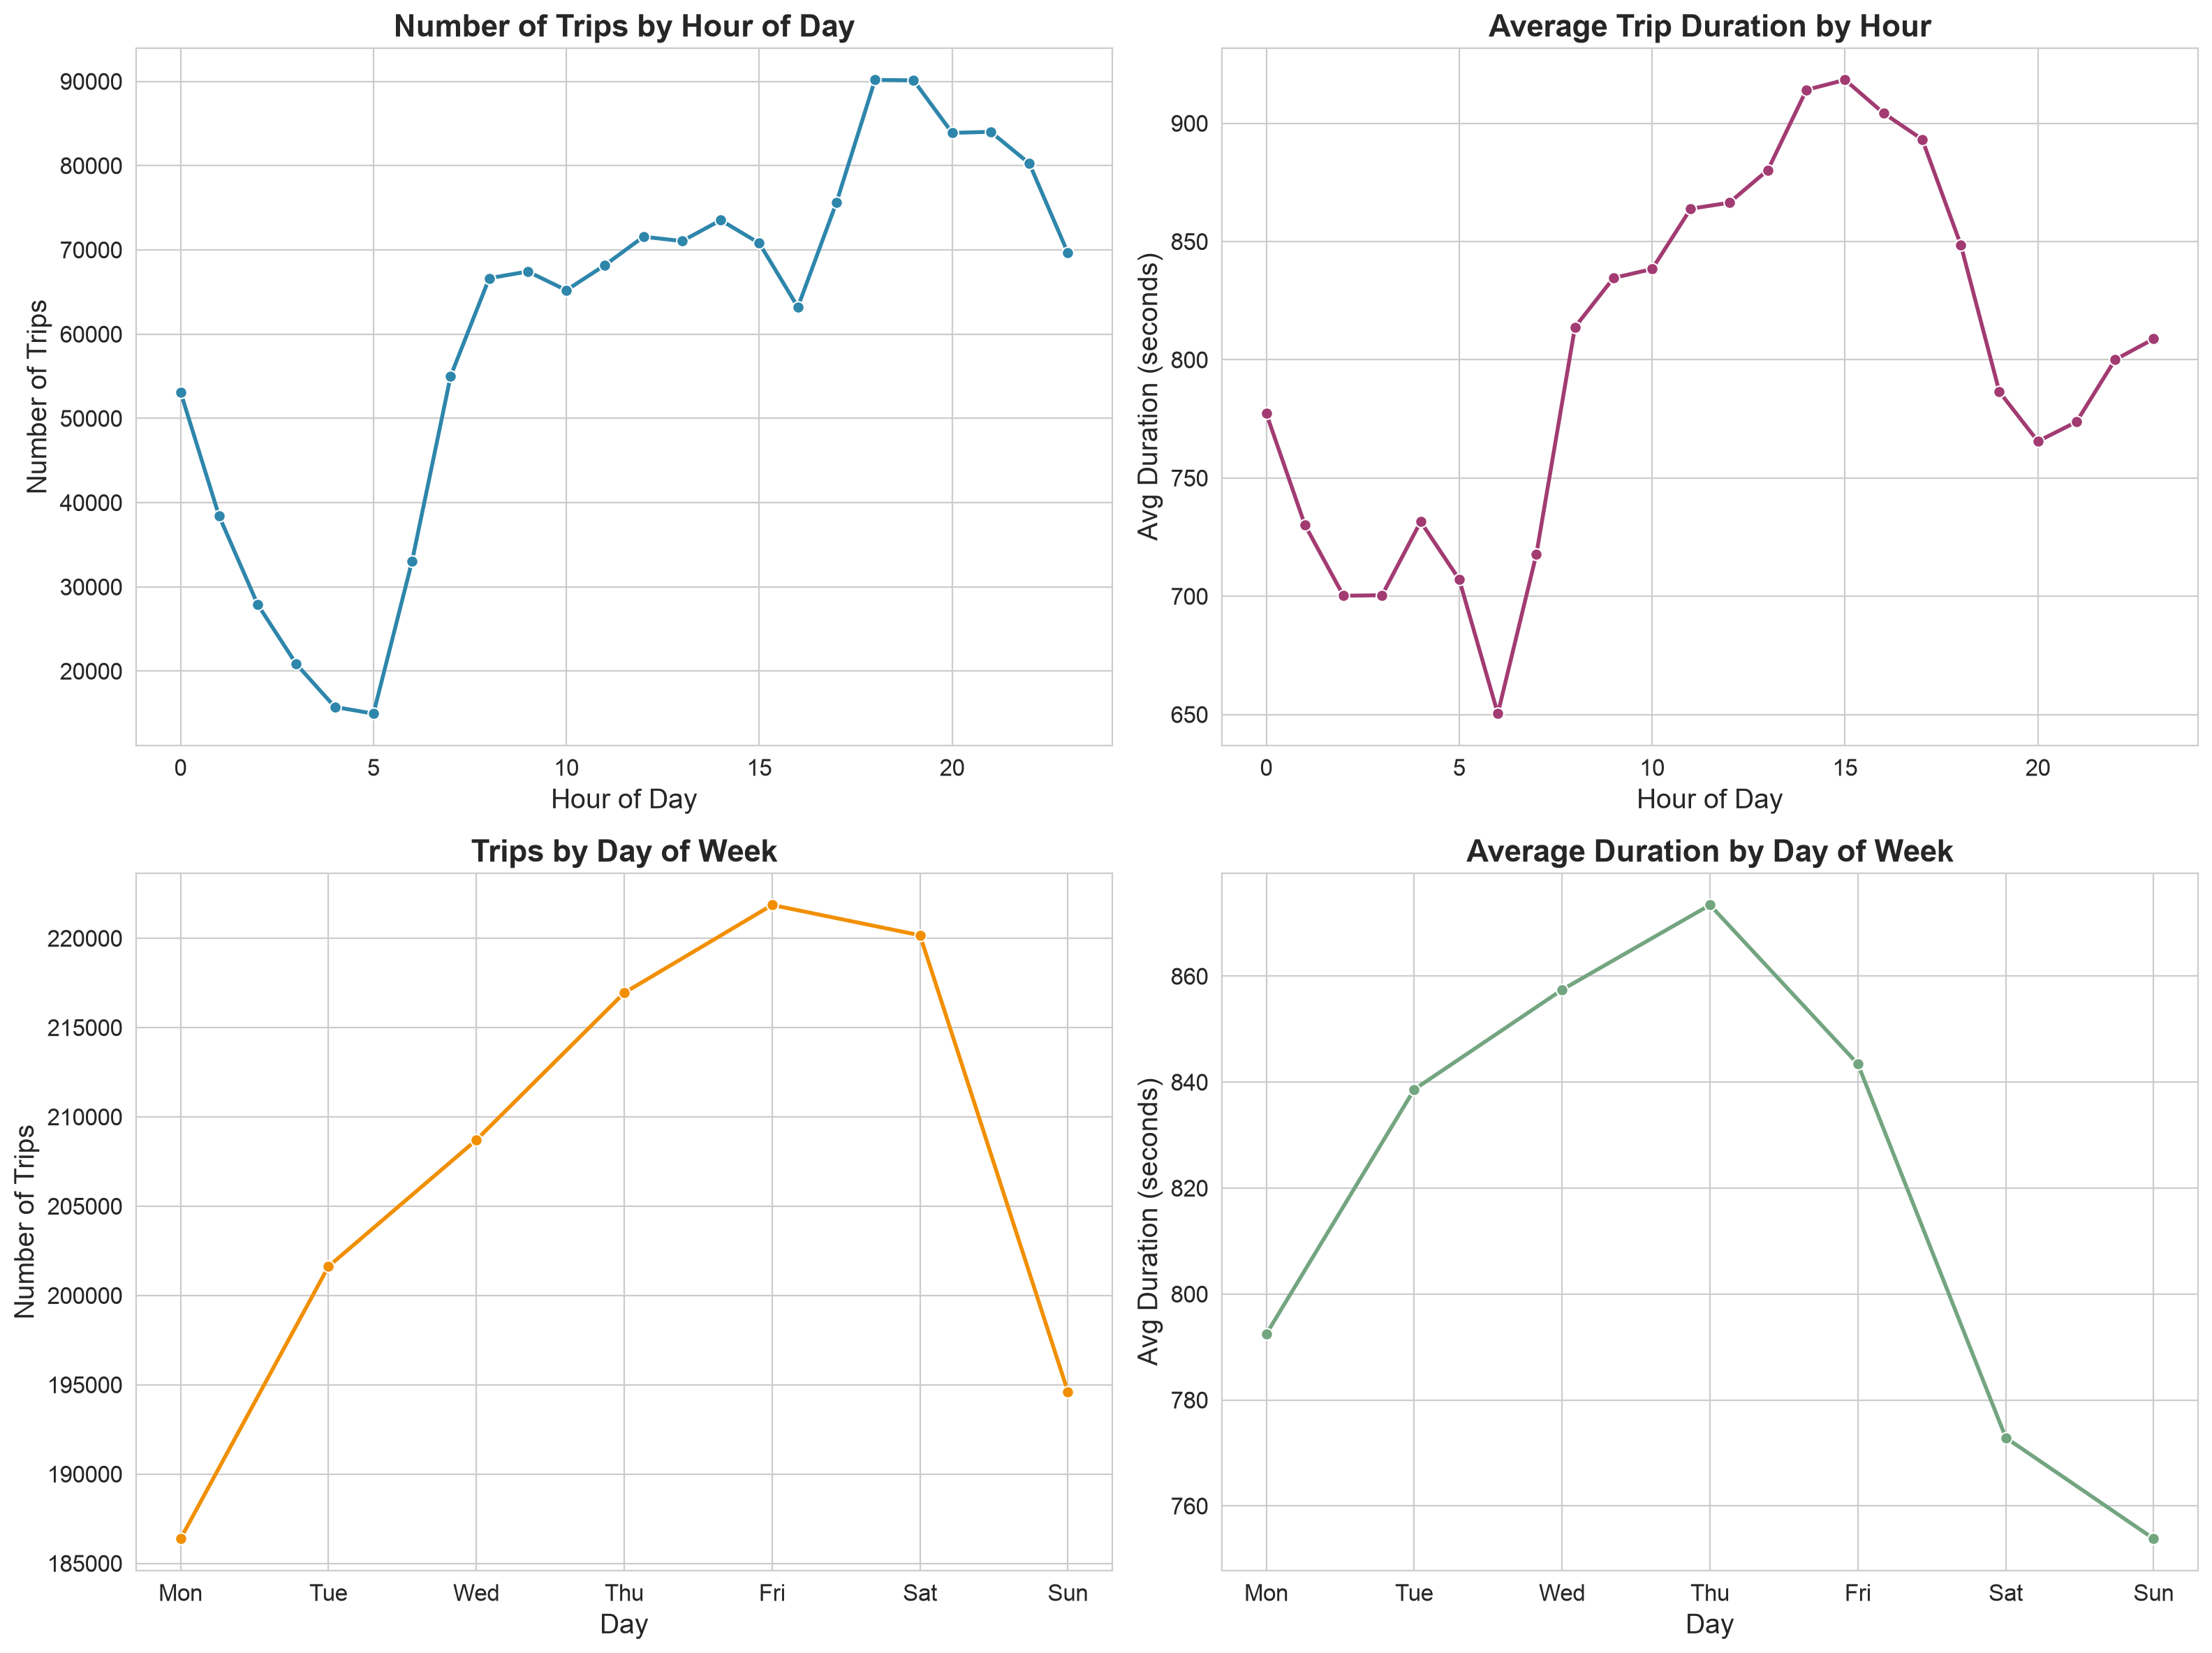

In [103]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Trip count by hour
hourly_counts = df.groupby('pickup_hour').size()
sns.lineplot(x=hourly_counts.index, y=hourly_counts.values, ax=axes[0, 0], color='#2E86AB', marker='o', linewidth=2)  # Changed to single color
axes[0, 0].set_title('Number of Trips by Hour of Day', fontweight='bold')
axes[0, 0].set_xlabel('Hour of Day')
axes[0, 0].set_ylabel('Number of Trips')

# 2. Average duration by hour
hourly_duration = df.groupby('pickup_hour')['trip_duration'].mean()
sns.lineplot(x=hourly_duration.index, y=hourly_duration.values, ax=axes[0, 1], color='#A23B72', marker='o', linewidth=2)  # Changed to single color
axes[0, 1].set_title('Average Trip Duration by Hour', fontweight='bold')
axes[0, 1].set_xlabel('Hour of Day')
axes[0, 1].set_ylabel('Avg Duration (seconds)')

# 3. Trip count by day of week
day_counts = df.groupby('pickup_dayofweek').size()
sns.lineplot(x=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'], 
            y=day_counts.values, ax=axes[1, 0], color='#F18F01', marker='o', linewidth=2)  # Changed to single color
axes[1, 0].set_title('Trips by Day of Week', fontweight='bold')
axes[1, 0].set_xlabel('Day')
axes[1, 0].set_ylabel('Number of Trips')

# 4. Average duration by day of week
day_duration = df.groupby('pickup_dayofweek')['trip_duration'].mean()
sns.lineplot(x=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'], 
            y=day_duration.values, ax=axes[1, 1], color='#73A580', marker='o', linewidth=2) 
axes[1, 1].set_title('Average Duration by Day of Week', fontweight='bold')
axes[1, 1].set_xlabel('Day')
axes[1, 1].set_ylabel('Avg Duration (seconds)')

plt.tight_layout()
plt.show()

> in the early morning, there isnt much trips.

> there isn't much trips on weekend.


/var/folders/ck/c5qrvbs975v8gh75gxmzv8g40000gn/T/ipykernel_39901/64637074.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='is_weekend', data=df, ax=axes[0], palette=['#2E86AB', '#A23B72'])
/var/folders/ck/c5qrvbs975v8gh75gxmzv8g40000gn/T/ipykernel_39901/64637074.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(['Weekday', 'Weekend'])
/var/folders/ck/c5qrvbs975v8gh75gxmzv8g40000gn/T/ipykernel_39901/64637074.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='is_weekend', y='trip_duration', data=df, ax=axes[1],
/var/folders/ck/c5qrv

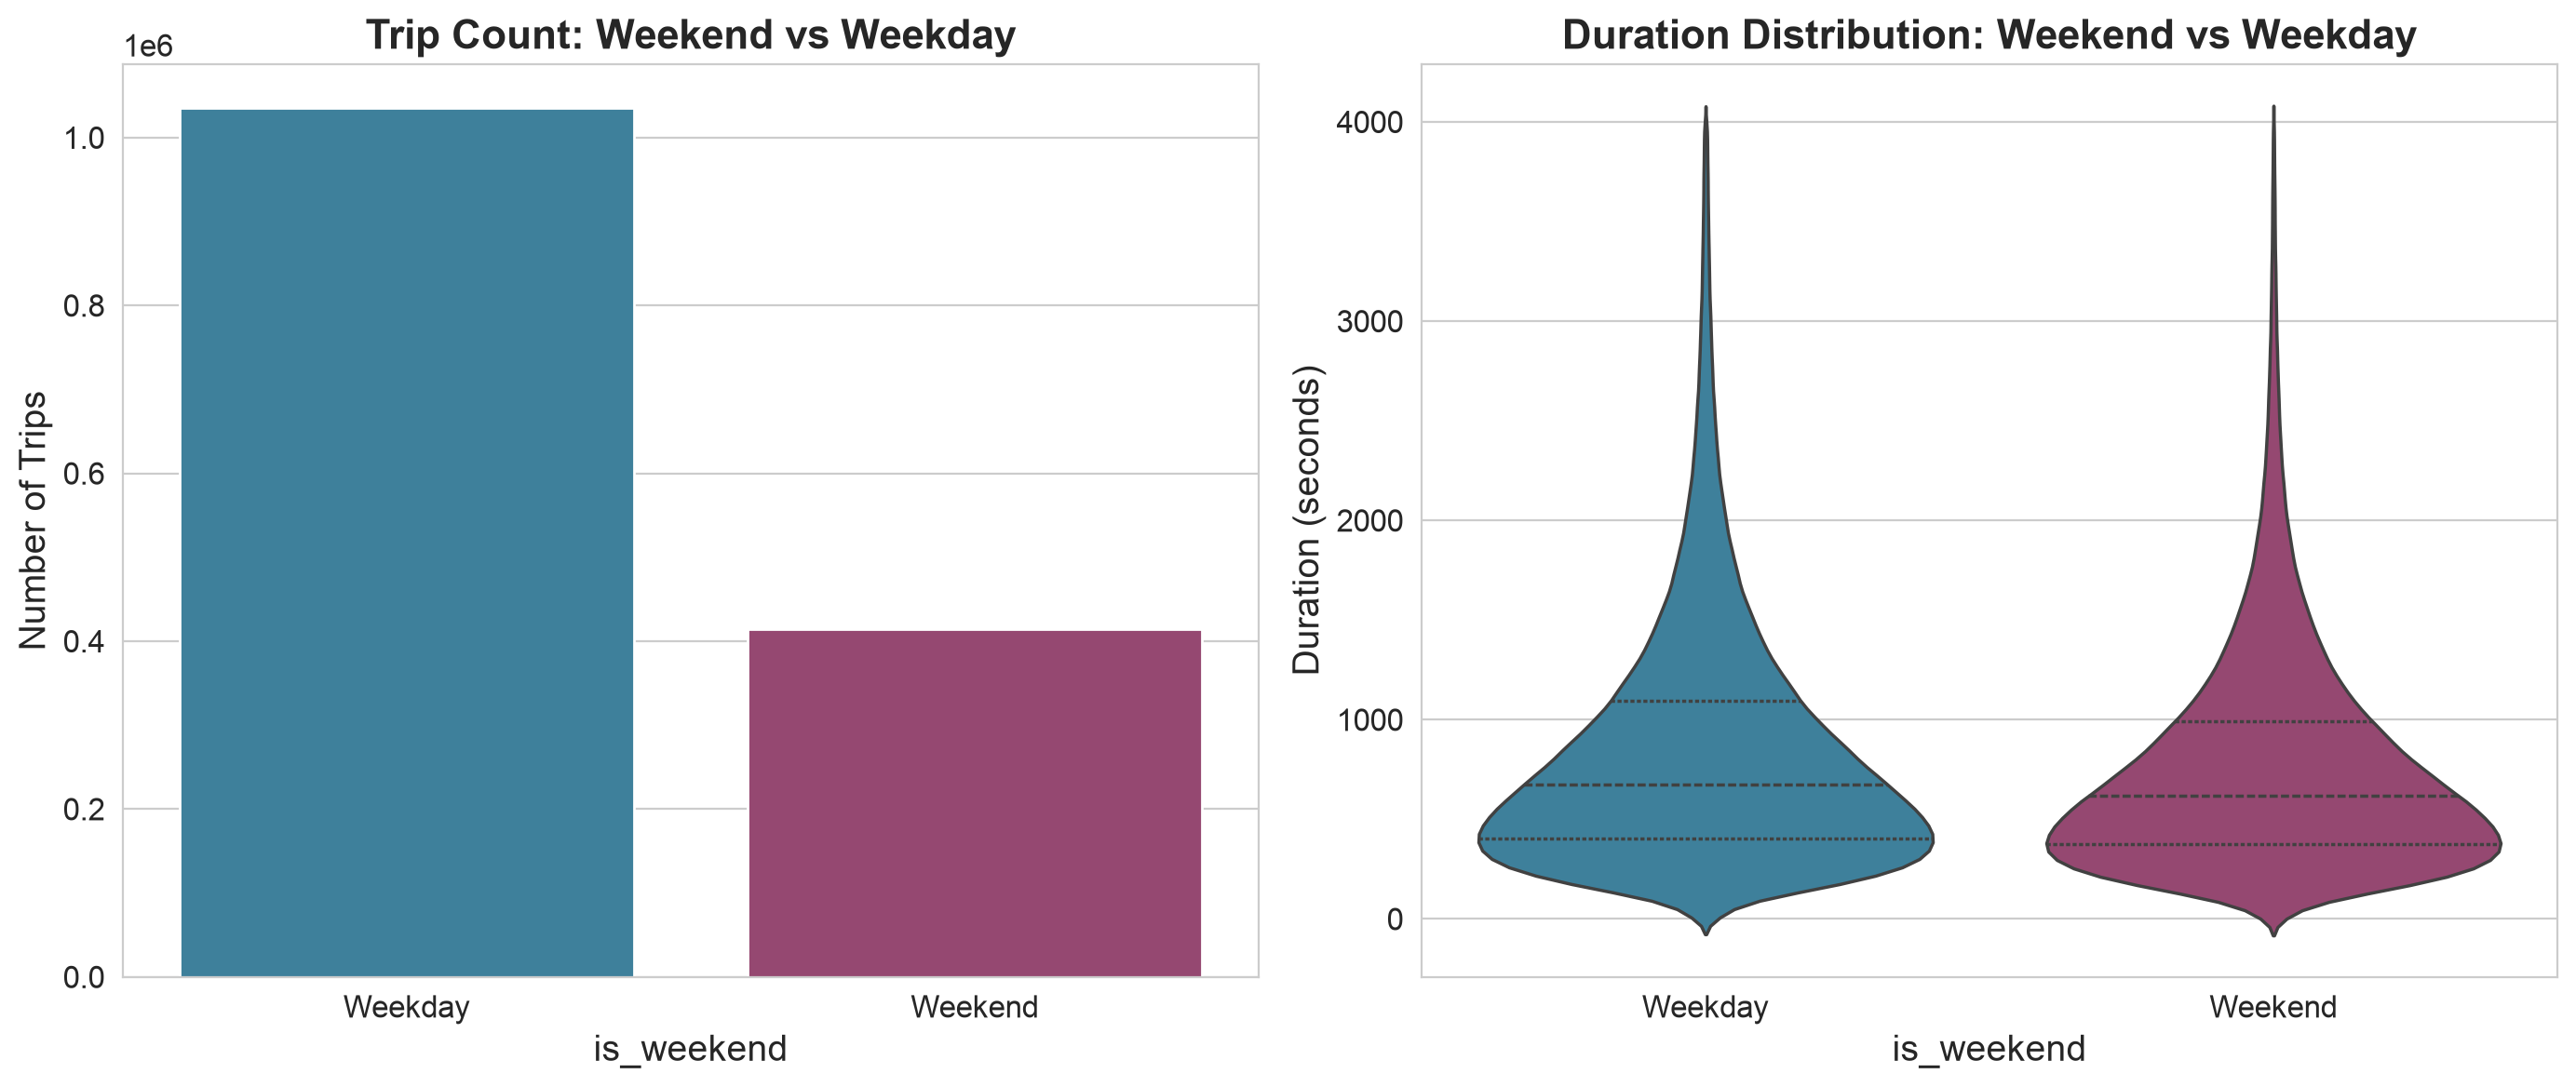


Duration Statistics:
                count        mean         std  min    25%    50%     75%  \
is_weekend                                                                 
0           1035551.0  842.413873  621.430555  1.0  405.0  676.0  1096.0   
1            414799.0  763.898119  556.678533  1.0  374.0  618.0   992.0   

               max  
is_weekend          
0           4000.0  
1           3997.0  


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Count plot
sns.countplot(x='is_weekend', data=df, ax=axes[0], palette=['#2E86AB', '#A23B72'])
axes[0].set_title('Trip Count: Weekend vs Weekday', fontweight='bold')
axes[0].set_xticklabels(['Weekday', 'Weekend'])
axes[0].set_ylabel('Number of Trips')

# Violin plot for duration distribution
sns.violinplot(x='is_weekend', y='trip_duration', data=df, ax=axes[1], 
               palette=['#2E86AB', '#A23B72'], inner='quartile')
axes[1].set_title('Duration Distribution: Weekend vs Weekday', fontweight='bold')
axes[1].set_xticklabels(['Weekday', 'Weekend'])
axes[1].set_ylabel('Duration (seconds)')

plt.tight_layout()
plt.show()

# Statistical summary
print("\nDuration Statistics:")
print(df.groupby('is_weekend')['trip_duration'].describe())

/var/folders/ck/c5qrvbs975v8gh75gxmzv8g40000gn/T/ipykernel_39901/282945551.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='passenger_count', data=df, ax=axes[0], palette='viridis')
/var/folders/ck/c5qrvbs975v8gh75gxmzv8g40000gn/T/ipykernel_39901/282945551.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='passenger_count', y='trip_duration', data=df, ax=axes[1], palette='viridis')
/var/folders/ck/c5qrvbs975v8gh75gxmzv8g40000gn/T/ipykernel_39901/282945551.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='passenger_count

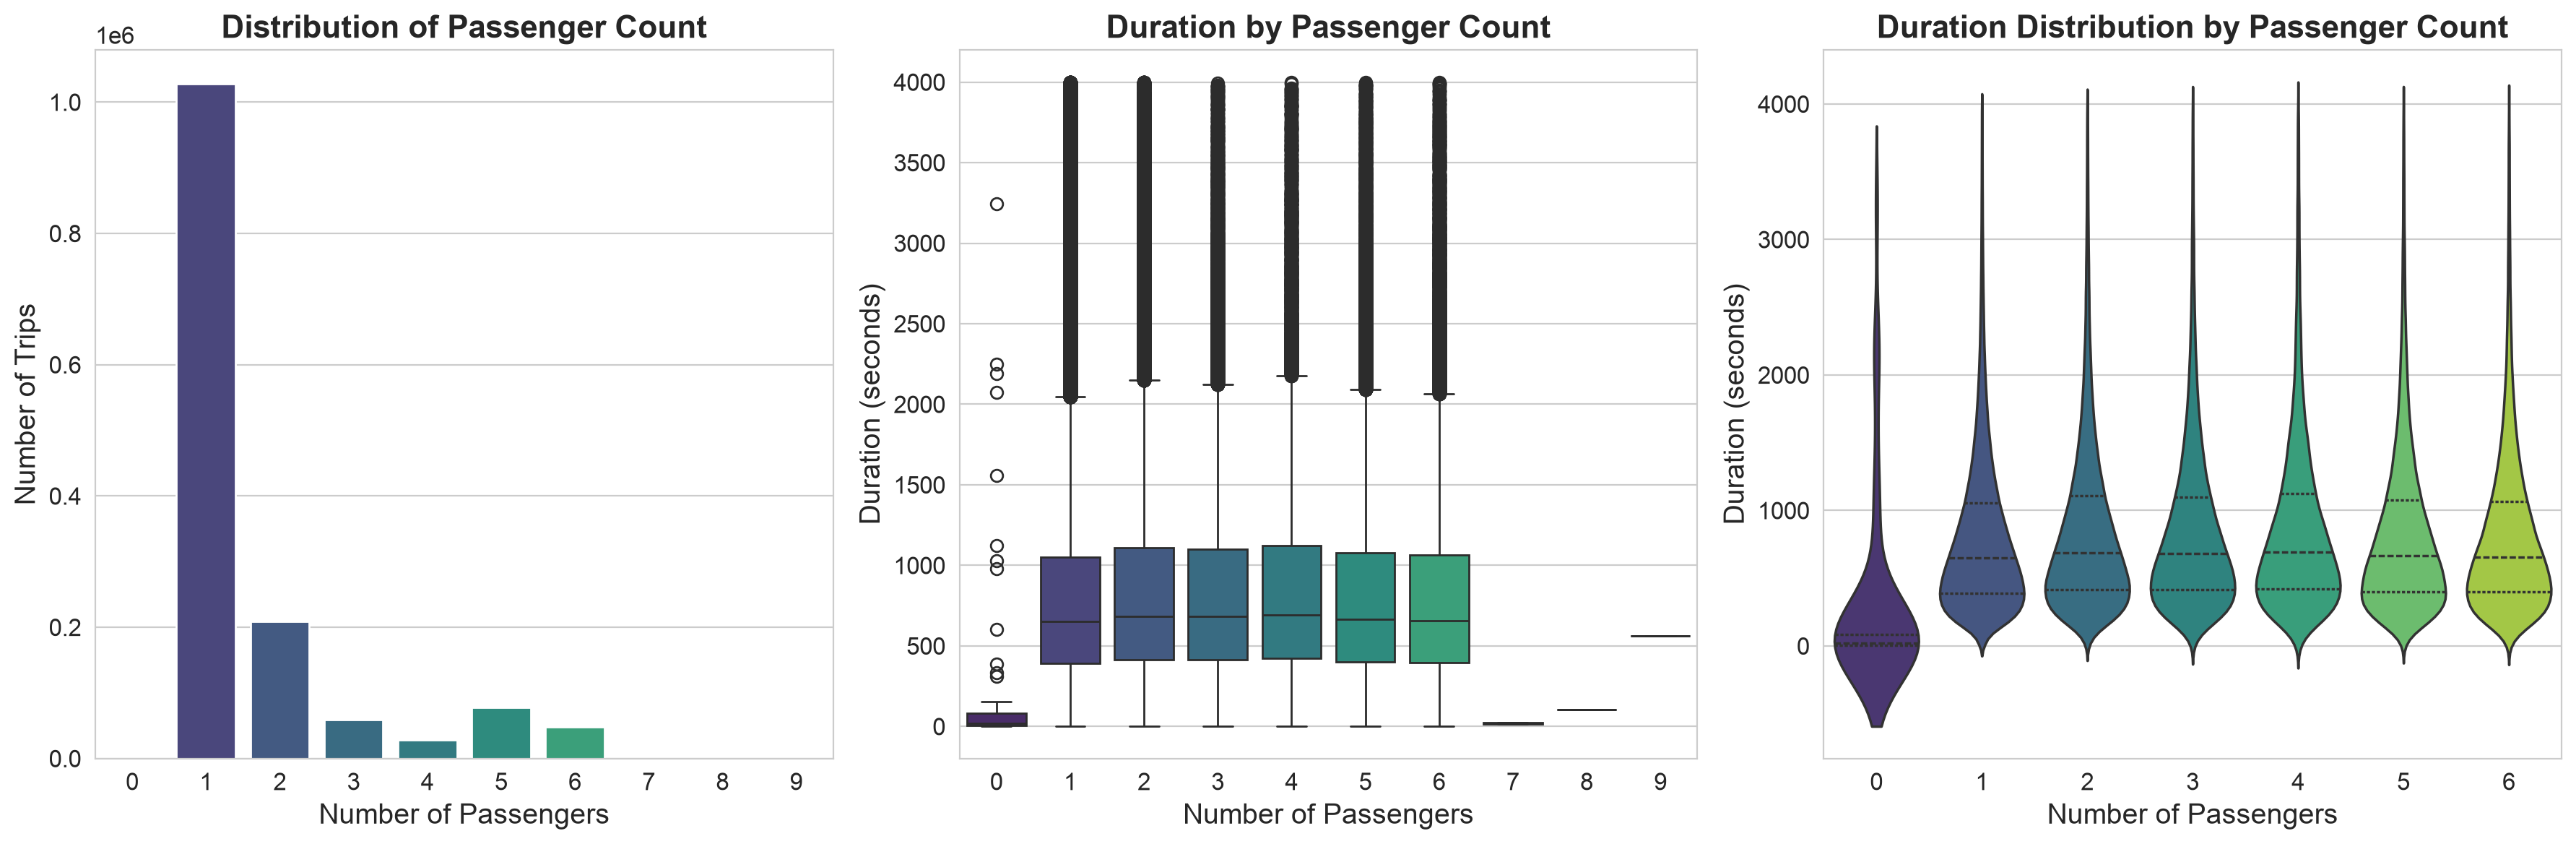

In [79]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Count plot
sns.countplot(x='passenger_count', data=df, ax=axes[0], palette='viridis')
axes[0].set_title('Distribution of Passenger Count', fontweight='bold')
axes[0].set_xlabel('Number of Passengers')
axes[0].set_ylabel('Number of Trips')

# Box plot by passenger count
sns.boxplot(x='passenger_count', y='trip_duration', data=df, ax=axes[1], palette='viridis')
axes[1].set_title('Duration by Passenger Count', fontweight='bold')
axes[1].set_xlabel('Number of Passengers')
axes[1].set_ylabel('Duration (seconds)')

# Violin plot for better distribution view (filtered)
filtered_pass = df[df['passenger_count'] <= 6]
sns.violinplot(x='passenger_count', y='trip_duration', data=filtered_pass, 
               ax=axes[2], palette='viridis', inner='quartile')
axes[2].set_title('Duration Distribution by Passenger Count', fontweight='bold')
axes[2].set_xlabel('Number of Passengers')
axes[2].set_ylabel('Duration (seconds)')

plt.tight_layout()
plt.show()

In [105]:
df = df.drop(columns=['passenger_count'])

> box plots are similar but the number of passengers ,differ, so the features is useless. we will drop it.

/var/folders/ck/c5qrvbs975v8gh75gxmzv8g40000gn/T/ipykernel_39901/1610334983.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='vendor_id', data=df, ax=axes[0, 1], palette=colors)
/var/folders/ck/c5qrvbs975v8gh75gxmzv8g40000gn/T/ipykernel_39901/1610334983.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='vendor_id', y='trip_duration', data=df, ax=axes[1, 0], palette=colors)
/var/folders/ck/c5qrvbs975v8gh75gxmzv8g40000gn/T/ipykernel_39901/1610334983.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='vendor_id', y='trip_dur

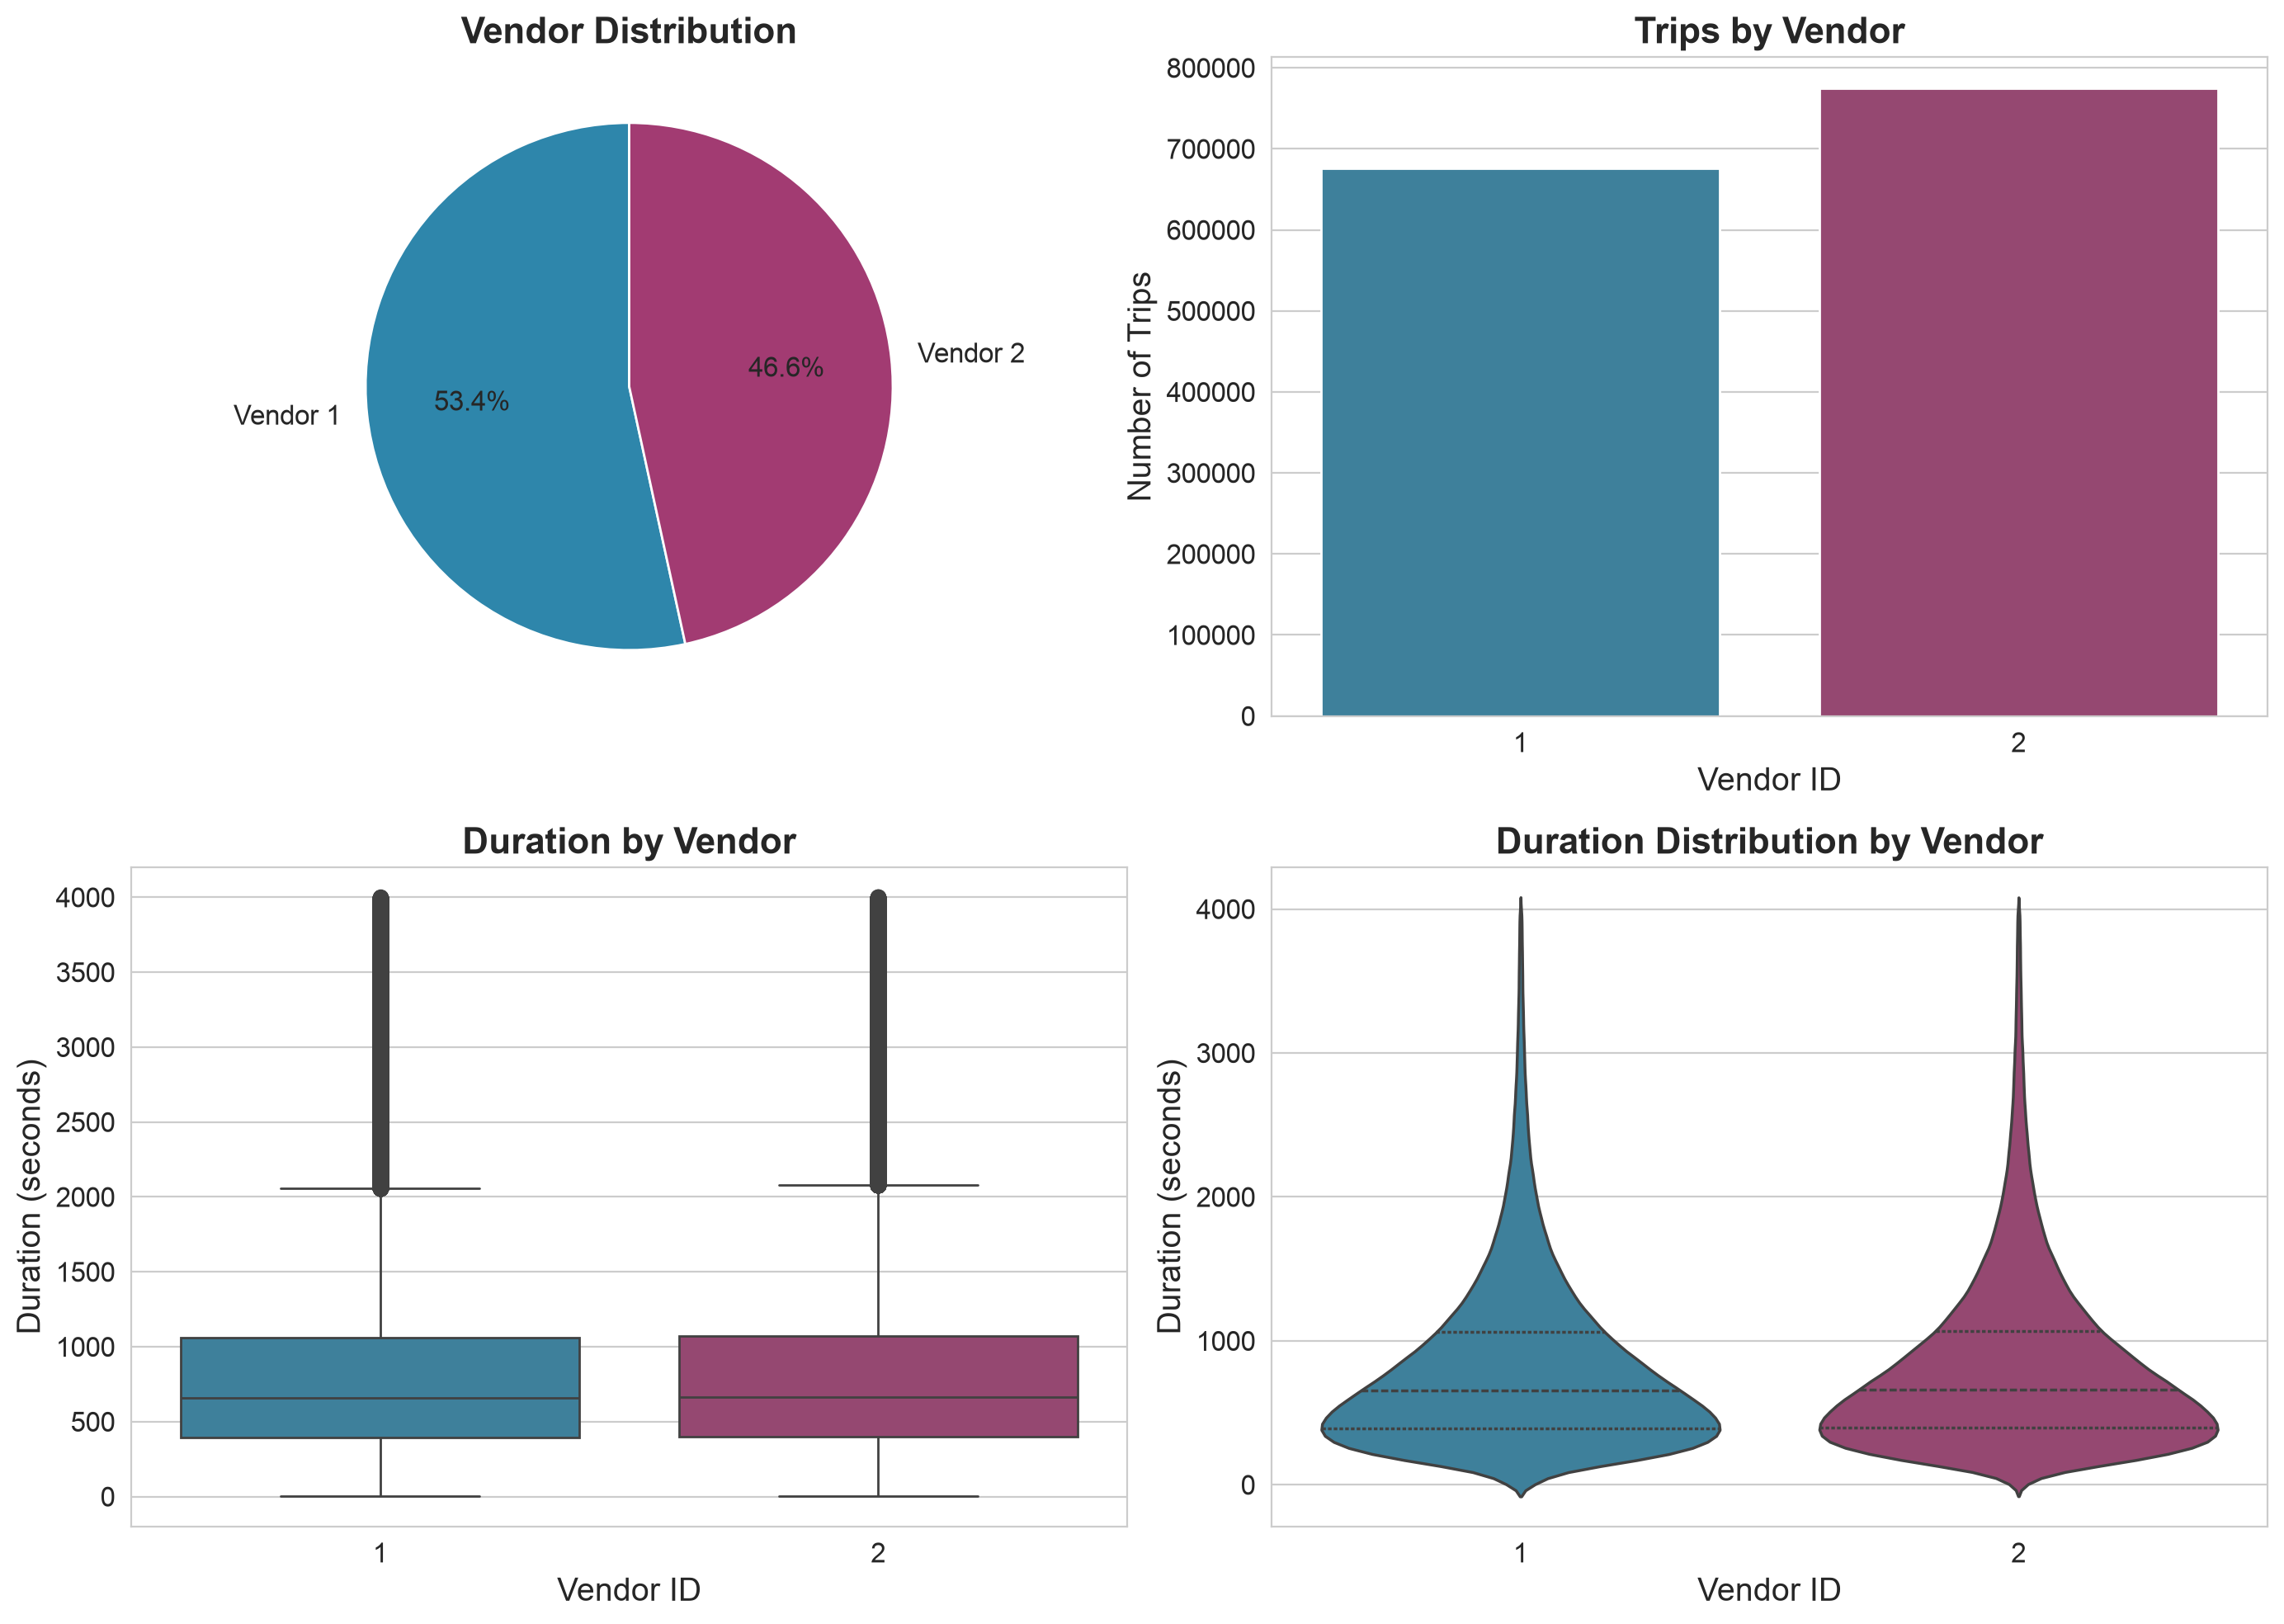


Vendor Statistics:
              count        mean         std  min    25%    50%     75%     max
vendor_id                                                                     
1          675587.0  814.845594  600.181064  1.0  394.0  656.0  1060.0  4000.0
2          774704.0  824.457354  608.486938  1.0  397.0  662.0  1070.0  4000.0


In [82]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Pie chart for vendor distribution
vendor_counts = df['vendor_id'].value_counts()
colors = ['#2E86AB', '#A23B72']
axes[0, 0].pie(vendor_counts.values, labels=['Vendor 1', 'Vendor 2'], 
               autopct='%1.1f%%', colors=colors, startangle=90)
axes[0, 0].set_title('Vendor Distribution', fontweight='bold')

# Count plot
sns.countplot(x='vendor_id', data=df, ax=axes[0, 1], palette=colors)
axes[0, 1].set_title('Trips by Vendor', fontweight='bold')
axes[0, 1].set_xlabel('Vendor ID')
axes[0, 1].set_ylabel('Number of Trips')

# Box plot by vendor
sns.boxplot(x='vendor_id', y='trip_duration', data=df, ax=axes[1, 0], palette=colors)
axes[1, 0].set_title('Duration by Vendor', fontweight='bold')
axes[1, 0].set_xlabel('Vendor ID')
axes[1, 0].set_ylabel('Duration (seconds)')

# Violin plot for vendor comparison
sns.violinplot(x='vendor_id', y='trip_duration', data=df, ax=axes[1, 1], 
               palette=colors, inner='quartile')
axes[1, 1].set_title('Duration Distribution by Vendor', fontweight='bold')
axes[1, 1].set_xlabel('Vendor ID')
axes[1, 1].set_ylabel('Duration (seconds)')

plt.tight_layout()
plt.show()

# Statistical comparison
print("\nVendor Statistics:")
print(df.groupby('vendor_id')['trip_duration'].describe())

In [104]:
print(df.groupby('vendor_id')['trip_duration'].mean())

vendor_id
1    814.845594
2    824.457354
Name: trip_duration, dtype: float64


it should be dropped as well

In [106]:
df = df.drop(columns=['vendor_id'])

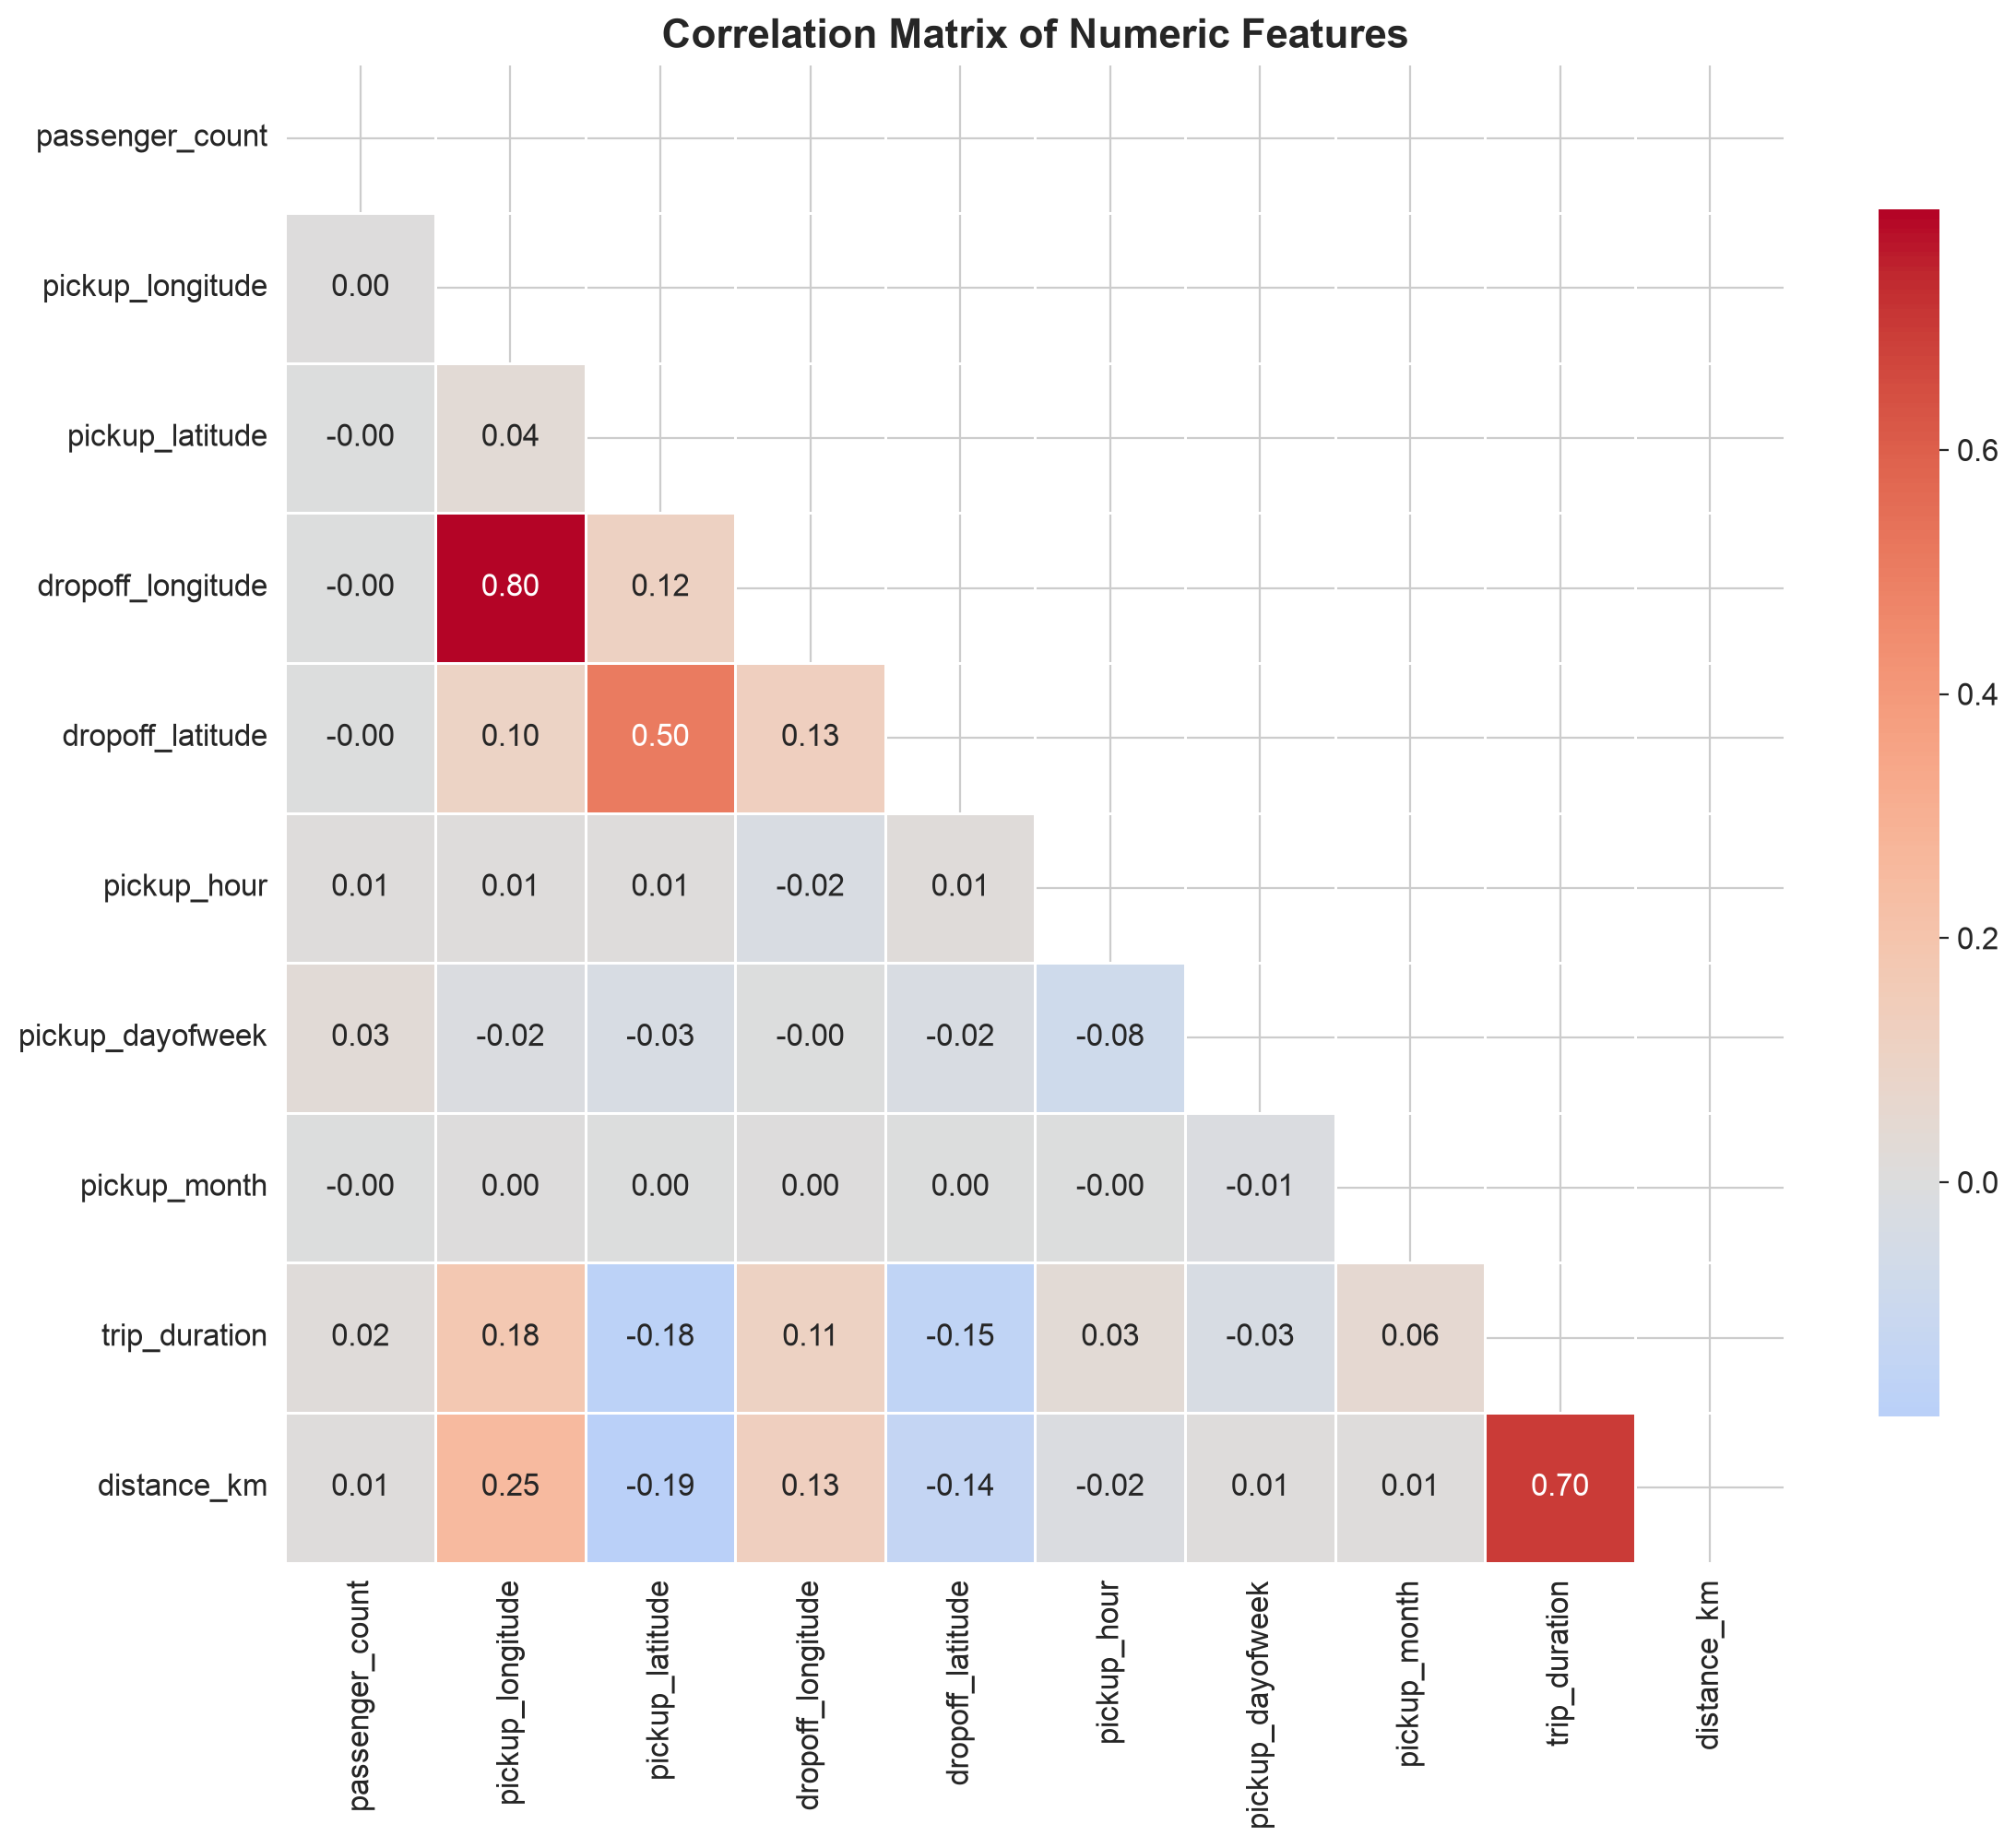


Correlations with trip_duration:
trip_duration        1.000000
distance_km          0.697604
pickup_longitude     0.175904
dropoff_longitude    0.106491
pickup_month         0.055038
pickup_hour          0.032990
passenger_count      0.015232
pickup_dayofweek    -0.031563
dropoff_latitude    -0.153610
pickup_latitude     -0.179531
Name: trip_duration, dtype: float64


In [83]:
# Select numeric columns
numeric_cols = [
    'passenger_count', 'pickup_longitude', 'pickup_latitude',
    'dropoff_longitude', 'dropoff_latitude', 'pickup_hour',
    'pickup_dayofweek', 'pickup_month', 'trip_duration', 'distance_km'
]

# Correlation matrix
correlation_matrix = df[numeric_cols].corr()

# Create a mask for upper triangle
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# Create heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm', 
            center=0, fmt='.2f', square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Numeric Features', fontweight='bold', fontsize=16)
plt.tight_layout()
plt.show()

# Focus on correlations with target
print("\nCorrelations with trip_duration:")
print(correlation_matrix['trip_duration'].sort_values(ascending=False))

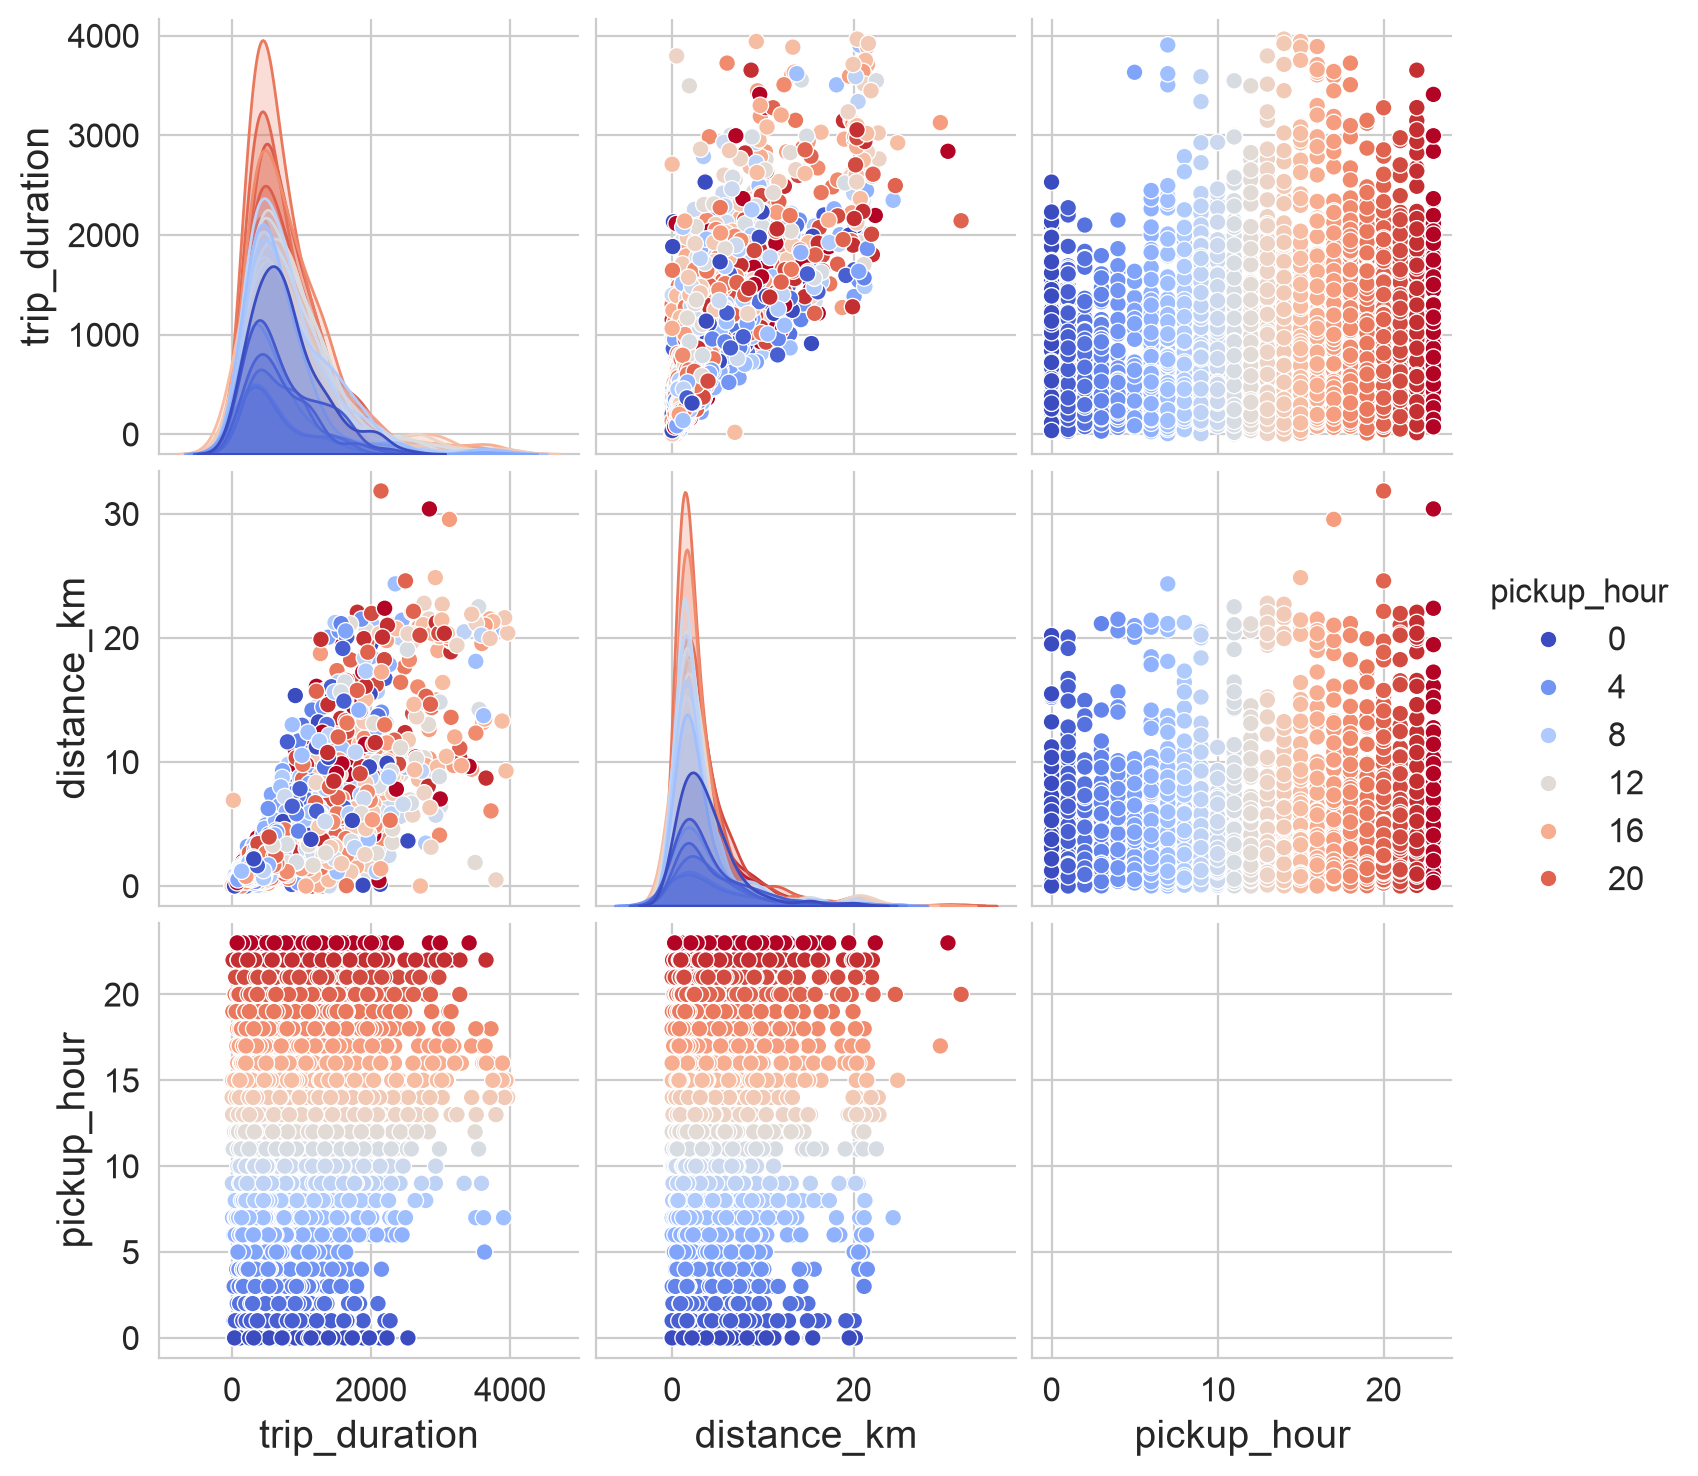

In [107]:

sns.pairplot(df.sample(5000), vars=['trip_duration', 'distance_km', 'pickup_hour', ], hue='pickup_hour', palette='coolwarm')
plt.show()

This is very interesting, we can see that small duration are usually at night, people prefer to take a taxi even for a short distance trip, maybe because it is dangerous at night.

In [44]:
df = df[df['distance_km'] > 0.1]